---
title: "Fick's law with Wilke's mixture rule for the effective diffusivity"
description: "Wilke's 1950 rule is exact when a species diffuses through gases that are genuinely stagnant, so reporting agreement there proves nothing. His own paper supplies the test that can fail: eight ternary film problems solved three ways, with the exact Stefan-Maxwell solution printed beside the rule. Recomputed here, the rule is wrong by up to 87 % - and the failure is not in the harmonic average but in the composition it is frozen at, which his own second method fixes to 12 %."
categories: [sec:A, struct:S3, tier:T0, data:tier6, phase:gas]
date: 2026-08-07
---

# Fick's law with Wilke's mixture rule for the effective diffusivity

**Catalog ID:** `A4.1` · **Structure:** `S3` (1-D steady BVP) · **Tier:** T0

Every reactor model that carries one diffusion coefficient per species in a
multicomponent gas is using some version of

$$
D'_A \;=\; \frac{1-y_A}{\dfrac{y_B}{D_{AB}}+\dfrac{y_C}{D_{AC}}+\dfrac{y_D}{D_{AD}}+\cdots}
$$

which is the equation printed in the abstract of Wilke (1950) and reprinted
forty-three years later as eq. (6.1.14) of Taylor and Krishna, with
`(Wilke, 1950)` inline. It is a weighted **harmonic** mean of the binary
diffusivities, and Wilke derives it from the Stefan–Maxwell equations for
"the effective diffusion coefficient of a gas with respect to a multicomponent
mixture of **stagnant** gases".

That last word is the whole problem with validating it. When species $i$ really
does diffuse through $n-1$ gases that carry no flux, the rule is not an
approximation at all — it is an algebraic identity, and any page that reports
agreement there is reporting arithmetic. So this page does not stop there.

Wilke's own paper contains the test that can fail. He sets up **eight ternary
test examples**, solves each one three ways — his rule (Method 1), a refinement
of it (Method 2), and the exact solution of the Stefan–Maxwell equations
(Method 3) — and prints all of it as Table 1. This page recomputes every cell of
that table from the printed inputs, solves the exact problem three independent
ways (a closed form derived here, a matrix exponential, and a pymrm
finite-volume solve), and measures how the rule fails.

**The result.** Against the exact solution of his own eight problems, the rule
is wrong by up to **87 %**, with a median of **22 %**. But the failure is not in
the harmonic average: replacing it with the weighted *arithmetic* mean that
J. H. Arnold attributes to Hougen and Watson in the paper's own printed
Discussion — "the latter is badly in error in some cases" — leaves the median
essentially unchanged (**22.2 %**) while making the worst case two and a half
times worse (**213 %**). What actually costs the accuracy is the *composition* the rule is
frozen at. Wilke's Method 2 uses the identical harmonic rule at a
flux-weighted film composition instead of the arithmetic mean, and the worst
error drops from 87 % to **12 %**.

Three printed defects are proved from the paper's own numbers along the way,
two printed typos are quoted with `[sic]` rather than corrected, and one
printed claim is checked and found to hold on the author's arithmetic and
fail on the true solution.

In [1]:
# Colab: install pymrm if it is not already present.
try:
    import pymrm  # noqa: F401
except ImportError:  # pragma: no cover
    %pip install -q pymrm

import sys, os, re, textwrap
from pathlib import Path

# make shared/gallery_utils.py importable locally and on Colab
_here = Path.cwd()
_cands = [_here.parents[1] / "shared", _here.parents[2] / "shared", _here / "shared"]
for _c in _cands:
    if (_c / "gallery_utils.py").exists():
        sys.path.insert(0, str(_c)); break
else:  # pragma: no cover - Colab, no checkout
    import urllib.request
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/computational-chemical-engineering/"
        "pymrm-gallery/main/shared/gallery_utils.py", "gallery_utils.py")
    sys.path.insert(0, ".")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as sp
from scipy.optimize import brentq
from scipy.integrate import quad
from scipy.sparse.linalg import spsolve
from pymrm import construct_grad, construct_div, NumJac
from gallery_utils import load_data, load_meta, report_agreement

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
np.set_printoptions(precision=6, suppress=False)
PAGE = "A4.1-wilke-mixture-rule"
print("numpy", np.__version__, "| pymrm", pymrm.__version__)

numpy 2.4.6 | pymrm 2.3.1.dev3+g93eeaefb4


## Background

### The paper, and which Wilke it is

C. R. Wilke, *"Diffusional Properties of Multicomponent Gases"*, **Chemical
Engineering Progress 46**(2) 95–104, February 1950 — presented at the Ninth
Regional Meeting, Los Angeles. The file used here is a microfilm scan whose text
layer is one of the two worst in this library (182 characters extract from
journal page 97; the by-line comes back as `C.R. WI E`), so **nothing here is
read from the text layer**. `pdfimages -list` reports JPEG grayscale at
400 × 400 ppi native, and every number on this page was read off a 400 dpi
render, cropped and re-read at digit scale. The identity was confirmed from the
document itself — title page, by-line, affiliation, running feet
(`Vol. 46, No. 2` / `CHEMICAL ENGINEERING PROGRESS` / `February, 1950`,
pages 95–104), the 30-item Literature Cited, and the signed Discussion — and
independently by Taylor and Krishna's reference list.

The name attaches to at least four different results and they get confused. The
one this page is about is the **gas-phase diffusion** mixture rule of
*Chem. Eng. Prog.* **46** (1950). It is **not**:

- the Buddenberg–Wilke **viscosity** mixture rule (*Ind. Eng. Chem.* **41**,
  1345, 1949; *J. Chem. Phys.* **18**, 517, 1950) — which is what Bird, Stewart
  and Lightfoot and Chapman and Cowling carry when they cite "Wilke", and which
  appears in *this* paper too, as eqs. (39)–(43) and Table 2, a separate topic
  scoped out below;
- Wilke and Lee's binary-diffusivity **estimation** correlation
  (*Ind. Eng. Chem.* **47**, 1253, 1955), which is a different paper, journal,
  year and equation;
- the Wilke–Chang liquid-diffusivity correlation.

### The second witness

Taylor and Krishna (1993), *Multicomponent Mass Transfer*, Wiley, is on disk and
is used here for three things only: it prints the rule as eq. (6.1.14) with
`(Wilke, 1950)` inline and states the condition — quoted as printed, stray
article and all: *"When species $i$ diffuses through **a** [sic] $n-1$ stagnant
gases and we have $N_j = 0$, $i \neq j$"*; its section 8.6
records the pedigree ("the oldest, simplest, and still widely used methods,
pioneered by Hougen and Watson (1947) and by Wilke (1950)"); and its
Example 8.5.1, explicitly "based on experiments conducted by Fairbanks and
Wilke (1950) with a view to assessing the validity of Wilke's effective
diffusivity formula", supplies a fully worked problem *in the stagnant regime*
with five printed intermediates. That example is reproduced here to show what
"exact" buys and what it does not.

### Scope

**In scope:** the diffusion half of the paper — eqs. (1)–(38), Table 1 in full,
the Example-VI sample calculation, and the Example-IV diffusivity averages.

**Out of scope, and why:**

- **Figure 1** (toluene into hydrogen–argon; ethyl propionate into hydrogen–air)
  is the paper's only experimental evidence, and it is a *figure*. Its data come
  from Fairbanks's 1948 M.S. thesis (the paper's ref. 10) and the paper says the
  experiments "are to be described in detail in a subsequent paper". Nothing on
  this page rests on it and it is not digitised. The paper's own Comment section
  is blunt about the consequence: validity of the Stefan–Maxwell equations "has
  not been established experimentally in multicomponent systems for other than
  the stagnant gas case cited here".
- **Figure 3** is *recomputed*, not traced: both of its curves follow from the
  paper's own eqs. (2) and (6) and the printed conditions of Example IV, and the
  two scalars the text prints beside it (2.15 and 2.22 sq.cm./sec.) are
  reproduced from that computation. Never trace a curve you can compute.
- **Gas mixture viscosities** (eqs. 39–43, Table 2) — the Buddenberg–Wilke
  result, a different catalogue case.
- **Equipment capacity coefficients** (eqs. 44–57) — the transfer-unit algebra
  that follows from the flux equations; it introduces no new closure.

## The published model

Notation is Wilke's own (journal p. 103): $p$ partial pressure in atm, $y$ mole
fraction, $N$ rate of diffusion in g.mole/(sq.cm.)(sec.), $x$ the effective film
thickness in cm, $R$ the gas constant in (cu.cm.)(atm.)/(g.mole)(°K).

### The rule — eq. (6)

For diffusion of $A$ into a mixture of gases $B, C, D, \dots$, Wilke writes the
Maxwell friction balance (his eq. 3), sets $U_B = U_C = \cdots = 0$ ("in the case
of all gases being stagnant except $A$"), and reaches

$$
D'_A \;=\; \frac{1-y_A}{\dfrac{y_B}{D_{AB}}+\dfrac{y_C}{D_{AC}}+\dfrac{y_D}{D_{AD}}+\cdots}
\tag{6}
$$

with the equivalent form (6a) in which the $y$'s are mole fractions "in the inert
gas portion considered separately from diffusing gas $A$", so that $D'_A$ "is
constant for a given inert gas composition and independent of the mole fraction
of $A$". A footnote records that "this result was partially anticipated by
Stefan".

### The flux equations — eqs. (9)–(17)

The defining rate equation for component $A$ of a multicomponent system is
Fick's law plus bulk flow,

$$
N_A \;=\; -\frac{D'_A P}{RT}\frac{\mathrm{d}y_A}{\mathrm{d}x} + N_t\,y_A ,
\tag{9}
$$

with $N_t$ the total net rate of transfer. Wilke introduces
$\phi_A = N_A/N_t$ (eq. 10) and integrates eq. (9) at constant $D''_A$ to

$$
N_A \;=\; \frac{\phi_A D''_A P}{RTx}\,\ln\frac{\phi_A - y_{A_2}}{\phi_A - y_{A_1}},
\tag{14}
$$

which he rearranges into the film-pressure-factor form

$$
N_A \;=\; \frac{D''_A P}{RTx\,(p_f)_A}\,(p_{A_1}-p_{A_2}),
\qquad
(p_f)_A = \frac{P}{\phi_A}\,(\phi_A-y_A)_{lm}.
\tag{15, 16}
$$

Eqs. (14) and (15) are the *same* equation; (14) is the form used below because
it stays finite as $N_t \to 0$. The two familiar limits are printed: for one gas
through a second stagnant gas $\phi_A = 1$ and $(p_f)_A = (P-p_A)_{lm}$, giving
the classic Stefan equation (20); for equimolal counterdiffusion
$\phi_A = \infty$ and $(p_f)_A = P$.

### Method 1 — the rule, at the arithmetic-mean composition

$$
D''_A = \frac{1-y'_A}{\dfrac{y'_B}{D_{AB}}+\dfrac{y'_C}{D_{AC}}+\cdots},
\qquad y'_A = \tfrac12\,(y_{A_1}+y_{A_2}),\ \ \text{etc.}
\tag{25}
$$

### Method 2 — the same rule, at an *effective film* composition

Wilke's own refinement. Partial film pressure factors are defined pairwise
(eqs. 30–32), for instance

$$
(p_f)_{AB} = \frac{P}{\phi_{AB}}\,(y'_A+y'_B)\,(\phi_{AB}-y'_{AB}),
\qquad
y'_{AB} = \frac{y'_A}{y'_A+y'_B},\quad \phi_{AB} = \frac{N_A}{N_A+N_B},
$$

normalised into effective mole fractions (eqs. 27–29),
$y''_B = (p_f)_{AB}/[(p_f)_{AB}+(p_f)_{AC}+\cdots]$, and fed back into the same
harmonic average (eq. 26):

$$
D''_A = \frac{1}{\dfrac{y''_B}{D_{AB}}+\dfrac{y''_C}{D_{AC}}+\cdots}.
\tag{26}
$$

One branch is stated in words and is live in the data: *"it is possible to
obtain a negative partial film pressure factor in Equations (30)-(32). In such
cases it is recommended that the presence of the component giving the negative
value be neglected … and its partial film pressure factor assumed equal to zero
in Equations (27)-(29)."* Example VIII takes that branch.

### Method 3 — the exact solution

For simultaneous diffusion of $A$ and $B$ through a third **stagnant** gas $C$
Wilke quotes Sherwood's differential equations,

$$
-\frac{P}{RT}\frac{\mathrm{d}p_A}{\mathrm{d}x}
=\left[\frac{1}{D_{AB}}-\frac{1}{D_{AC}}\right]N_A p_B
-\left[\frac{N_B}{D_{AB}}+\frac{N_A}{D_{AC}}\right]p_A + \frac{N_A P}{D_{AC}},
\tag{21}
$$

with eq. (22) the same expression under $A \leftrightarrow B$, and Gilliland's
integral

$$
\frac{N_A}{D_{AC}}+\frac{N_B}{D_{BC}} = \frac{P}{RTx}\,\ln\frac{p_{C_2}}{p_{C_1}}
\tag{23}
$$

together with eq. (24). Rates "calculated by Equations (21)–(24) are tabulated
under method 3 in Table 1, and are considered to be correct solutions to these
examples to be used for testing the approximate methods."

### These are the Stefan–Maxwell equations, and that is checked below

Writing the standard Maxwell–Stefan balance for an ideal ternary at constant
$T$, $P$, with $c = P/RT$,

$$
\frac{\mathrm{d}y_i}{\mathrm{d}x} \;=\; \sum_{j\neq i}\frac{y_i N_j - y_j N_i}{c\,D_{ij}},
$$

and imposing $N_C = 0$ reproduces eq. (21) term for term — the derivation is
carried out in the notebook. **It reproduces eq. (22) only after one printed
subscript is corrected**, and eq. (23) then follows in three lines as the exact
integral of the $C$ equation. Both facts are used below.

## Parameters and assumptions

All eight examples share the conditions printed in Table 1's own footnote and
repeated on journal p. 98:

| quantity | value | source |
|---|---|---|
| diffusion distance $x = x_2-x_1$ | 0.1 cm | Table 1 footnote |
| total pressure $P$ | 150 mm Hg | Table 1 footnote |
| temperature $T$ | 40 °C | Table 1 footnote |
| system | H₂ – H₂O – CO₂ | journal p. 98 |
| $D_{\mathrm{CO_2\text{-}H_2O}}$, $D_{\mathrm{CO_2\text{-}H_2}}$, $D_{\mathrm{H_2O\text{-}H_2}}$ | 0.9220, 2.7064, 3.4576 sq.cm./sec. | Table 1, three distinct values |

Assumptions, all Wilke's:

1. **Steady state, one dimension, constant $T$ and $P$.** $N_A$ and $N_B$ are
   constants of the problem.
2. **Gas $C$ is stagnant in every example**: $N_C = 0$. This is what makes the
   problem two-dimensional in the unknowns and what makes eq. (23) exact.
3. **Ideal gas.** $c = P/RT$ is uniform.
4. The diffusion coefficients are *not* real: the table's own dagger footnote
   says they "are estimated and do not correspond to true values". Nothing on
   this page is a statement about carbon dioxide, water or hydrogen; every
   number is a statement about the *methods*, compared with each other on
   identical inputs.
5. $R = 82.06$ and $T = 313.15$ K. The paper prints neither. The break table
   shows every *reported deviation* is insensitive to both at the $10^{-4}$
   level, because all of them are ratios in which $c = P/RT$ cancels.

**Fit or test?** Neither, and the distinction still matters. Nothing on this page
is fitted to anything: there is no adjustable parameter anywhere in Methods 1, 2
or 3. What the page reports is a **model-versus-model** comparison on the
author's own eight problems, using the author's own exact solution as the
reference — a *reproduction*, not a *validation*. The only experimental content
in the paper is Figure 1, which is scoped out, so **no number on this page is
tested against a measurement**, and the page never says otherwise.

## The data

Three tier-6 datasets, all of them the authors' own computations. No page
image is reproduced and no figure is digitised.

- `wilke-1950-table1.csv` — every cell of Table 1 (journal p. 99), which is
  printed rotated 90° and was rendered at native 400 ppi, rotated losslessly and
  read cell by cell.
- `wilke-1950-printed-intermediates.csv` — the twelve printed steps of the
  Example-VI sample calculation (journal p. 101), the five numbers of the
  Example-VI film-pressure-factor paragraph (p. 99), the two Example-IV
  diffusivity averages, and the paper's own accuracy claim for Method 2.
- `taylor-krishna-1993-example-8-5-1.csv` — Taylor and Krishna's worked
  evaporation example, printed pages 201–203.

**No other page's dataset is loaded**, so the cross-page reconciliation rule does
not apply. The related page `A4.2` reaches a Wilke-versus-Maxwell–Stefan
comparison from Krishna and Wesselingh (1997) on the Duncan–Toor two-bulb
experiment; it shares no dataset, no solver and no number with this page.

### Three self-consistency checks the table imposes on itself

Before anything is computed *from* the table, three constraints check what was
read *off* it. All three are properties of the printed table alone.

In [2]:
T1 = load_data("wilke-1950-table1.csv", page=PAGE)
# the same file re-read as text, so that print-rounding bounds can be taken from
# the LITERAL the paper prints rather than inferred from a float's repr (a
# printed trailing zero, "0.330", would otherwise be counted as two figures)
T1S = load_data("wilke-1950-table1.csv", page=PAGE, dtype=str)
PI = load_data("wilke-1950-printed-intermediates.csv", page=PAGE)
TK = load_data("taylor-krishna-1993-example-8-5-1.csv", page=PAGE)
tk = dict(zip(TK.quantity, TK.value))
pi = {(r.quantity, str(r.example), str(r.method)): r.value for r in PI.itertuples()}

P_MM, XLEN, T_K, R_GAS = 150.0, 0.1, 313.15, 82.06      # mm Hg, cm, K, cc atm/mol/K
P_ATM = P_MM / 760.0
C_TOT = P_ATM / (R_GAS * T_K)                            # mol/cm3
SCALE = 1e5                                              # Table 1's multiplier

BASE = T1.drop_duplicates("example").set_index("example")
EXN = list(BASE.index)


def _sigfigs(lit):
    """Significant figures in a printed decimal literal, trailing zeros kept."""
    d = str(lit).strip().lstrip("+-").replace(".", "").lstrip("0")
    return len(d)


def _half(v, sig):
    """Half a unit in the last printed digit of a value printed to `sig` figures."""
    return 0.5 * 10.0 ** (np.floor(np.log10(abs(v))) - sig + 1)


SIG = {(r.example, int(r.m3_set), c): _sigfigs(getattr(r, c))
       for r in T1S.itertuples() for c in ("m3_NA", "m3_NB")
       if isinstance(getattr(r, c), str)}
# a printed pressure is rounded by half a unit in ITS last printed digit too
PSTEP = {(r.example, c): 10.0 ** (-(len(str(getattr(r, c)).split(".")[1])
                                    if "." in str(getattr(r, c)) else 0))
         for r in T1S.drop_duplicates("example").itertuples()
         for c in ("p1_C", "p2_C")}

# ---- check 1: the six partial pressures of every row sum to exactly 150 mm Hg
s1 = BASE[["p1_A", "p1_B", "p1_C"]].sum(axis=1)
s2 = BASE[["p2_A", "p2_B", "p2_C"]].sum(axis=1)
sum_dev = float(np.max(np.abs(np.r_[s1.values, s2.values] - P_MM)))
print(f"check 1  16 partial-pressure sums, max |sum - 150 mm| = {sum_dev:.3e} mm Hg")

# ---- check 2: 24 diffusivity cells are three numbers, assigned pair-consistently
VALS = {}
for e, r in BASE.iterrows():
    for lab, D in (("AB", r.D_AB), ("AC", r.D_AC), ("BC", r.D_BC)):
        pair = frozenset((r[f"gas_{lab[0]}"], r[f"gas_{lab[1]}"]))
        VALS.setdefault(pair, set()).add(D)
print(f"check 2  {3*len(BASE)} diffusivity cells -> {len(VALS)} distinct gas pairs, "
      f"each with {[len(v) for v in VALS.values()]} distinct value(s)")
for pair, v in VALS.items():
    print(f"           {'-'.join(sorted(pair)):>10} : {sorted(v)[0]:.4f}")
pair_consistent = all(len(v) == 1 for v in VALS.values())

# ---- check 3: the exponent glyph.  Both the Table 1 header multiplier and the
# exponent on journal p. 101 are illegible at native resolution.  Arithmetic,
# not pixel shape, fixes them: Method 1 for Example I is recomputed below and
# lands on 5.799e-5 against a printed 5.80, and the p. 101 chain closes on
# -1.049e-6 against a printed -0.105.  Both force the multiplier to 1e5.
print(f"check 3  multiplier set to {SCALE:.0e} by arithmetic (see Results); "
      "the printed glyph is not legible at 400 ppi and is not used")
print(f"\nc = P/RT = {C_TOT:.6e} mol/cm3   (P = {P_ATM:.6f} atm, T = {T_K} K, R = {R_GAS})")

check 1  16 partial-pressure sums, max |sum - 150 mm| = 0.000e+00 mm Hg
check 2  24 diffusivity cells -> 3 distinct gas pairs, each with [1, 1, 1] distinct value(s)
              CO2-H2O : 0.9220
               CO2-H2 : 2.7064
               H2-H2O : 3.4576
check 3  multiplier set to 1e+05 by arithmetic (see Results); the printed glyph is not legible at 400 ppi and is not used

c = P/RT = 7.680575e-06 mol/cm3   (P = 0.197368 atm, T = 313.15 K, R = 82.06)


Check 1 is exact on all sixteen sums, which is what fixes the
five-figure entries (49.055 / 49.945, 49.528 / 49.972, 50.945 / 50.055,
50.472 / 50.028); a single mis-read digit anywhere in those eight cells would
show up as a 0.001–0.5 mm residue. Check 2 collapses 24 cells onto three
numbers and, crucially, passes on rows VI and VII where $A$ and $C$ are
permuted — a mis-assignment there is the single most likely transcription error
in the table and it would break the check.

Check 3 is the case the playbook singles out: an ambiguous glyph settled by
arithmetic rather than by pixel shape. Neither exponent is legible at 400 ppi
(both are shown below to be consistent only with $10^{5}$).

## PyMRM implementation

### The Stefan–Maxwell film, and Wilke's eqs. (21)–(23) derived from it

With $c = P/RT$ constant, $N_C = 0$, and $y_C = 1-y_A-y_B$, the Maxwell–Stefan
balances for $A$ and $B$ are **linear in $(y_A, y_B)$ with constant
coefficients**:

$$
-c\,\frac{\mathrm{d}y_A}{\mathrm{d}x}
= N_A\!\left(\frac{y_B}{D_{AB}}+\frac{y_C}{D_{AC}}\right) - N_B\frac{y_A}{D_{AB}},
\qquad
-c\,\frac{\mathrm{d}y_B}{\mathrm{d}x}
= N_B\!\left(\frac{y_A}{D_{AB}}+\frac{y_C}{D_{BC}}\right) - N_A\frac{y_B}{D_{AB}} .
$$

Multiplying the first by $P$ and substituting $p = Py$ gives Wilke's eq. (21)
**term for term**. The second gives his eq. (22) only if the bracket
$[1/D_{AB} - 1/D_{AC}]$ is read as $[1/D_{AB} - 1/D_{BC}]$; that is proved to be
a misprint below, from the paper's own eq. (23).

Adding the two and using $y_A+y_B = 1-y_C$ collapses everything except a term in
$y_C$:

$$
c\,\frac{\mathrm{d}y_C}{\mathrm{d}x} = \left(\frac{N_A}{D_{AC}}+\frac{N_B}{D_{BC}}\right) y_C
\;\Longrightarrow\;
\frac{N_A}{D_{AC}}+\frac{N_B}{D_{BC}} = \frac{c}{x}\ln\frac{y_{C_2}}{y_{C_1}},
$$

which is exactly eq. (23). It is used three ways: to reduce the exact problem to
a **one-dimensional** root find, as a constraint on the *printed* Method-3
numbers, and as the proof that eq. (22)'s subscript is wrong.

### Three routes to the exact answer

| route | what it is | what it can catch |
|---|---|---|
| **closed form** | the linear system integrated analytically: $y_C$ is one eigenmode with rate $\lambda_C$, and $f = N_B y_A - N_A y_B$ obeys $f' = \lambda_2 f - (Q/c)\,y_C$ with $\lambda_2 = N_t/(cD_{AB})$ | everything except an error in this derivation |
| **matrix exponential** | $\dot{y} = My + b$ propagated with a closed-form $2\times2$ $\exp(Mx)$, no eigen-decomposition of the problem structure | an error in the closed-form derivation |
| **pymrm finite volume** | `construct_grad` + `construct_div`, face-wise $[B]^{-1}$, `NumJac` + Newton | a discretisation or operator misuse; refines to the other two at second order |

The first two share no algebra beyond the definition of $M$; the third shares
nothing at all with either. A break row that moves all three together is a break
in the *physics*; one that moves only the third is a break in the *solver*.

In [3]:
# =========================================================== problem definition
def unpack(e):
    """(names, y1, y2, D_AB, D_AC, D_BC) for a Table-1 example, mole fractions."""
    r = BASE.loc[e]
    y1 = np.array([r.p1_A, r.p1_B, r.p1_C]) / P_MM
    y2 = np.array([r.p2_A, r.p2_B, r.p2_C]) / P_MM
    return (r.gas_A, r.gas_B, r.gas_C), y1, y2, r.D_AB, r.D_AC, r.D_BC


def Dmat(DAB, DAC, DBC):
    return np.array([[np.nan, DAB, DAC], [DAB, np.nan, DBC], [DAC, DBC, np.nan]])


# ================================================== the two mixture rules
def wilke_rule(y, i, D):
    """Eq. (6)/(25): weighted HARMONIC mean of the binaries."""
    return (1.0 - y[i]) / sum(y[j] / D[i, j] for j in range(3) if j != i)


def arith_rule(y, i, D):
    """Null baseline: weighted ARITHMETIC mean.  The paper's own printed
    Discussion (J. H. Arnold, journal p. 104) says Wilke's expression 'is simply
    a weighted harmonic mean, as opposed to the weighted arithmetic mean
    suggested by Hougen and Watson; the latter is badly in error in some cases'.
    Same weights y_j, arithmetic instead of harmonic.  Hougen and Watson's own
    text was NOT consulted; this is the form Arnold's sentence names."""
    return sum(y[j] * D[i, j] for j in range(3) if j != i) / (1.0 - y[i])


# ================================================== exact route 1: closed form
def exact_closed(NA, NB, y1, DAB, DAC, DBC, x=XLEN):
    """(y_A, y_B) at x from the analytic solution of the linear SM system."""
    NA, NB = np.asarray(NA, float), np.asarray(NB, float)
    yA1, yB1, yC1 = y1
    Nt = NA + NB
    lamC = (NA / DAC + NB / DBC) / C_TOT           # the y_C eigenmode
    lam2 = Nt / (C_TOT * DAB)                      # the A-B eigenmode
    Q = NA * NB * (1.0 / DAC - 1.0 / DBC)
    yC = yC1 * np.exp(lamC * x)
    d = lamC - lam2
    fp = np.where(d != 0, -Q * yC1 / (C_TOT * np.where(d == 0, 1.0, d)), np.nan)
    f = (NB * yA1 - NA * yB1 - fp) * np.exp(lam2 * x) + fp * np.exp(lamC * x)
    yA = np.where(Nt != 0, (f + NA * (1.0 - yC)) / np.where(Nt == 0, 1.0, Nt), np.nan)
    return yA, 1.0 - yC - yA


# ============================================ exact route 2: matrix exponential
def _matfun2(M, t, f, fp):
    """f(M t) for a batch of 2x2 matrices, from the two eigenvalues.

    Any analytic f satisfies f(A) = f0 I + f1 A with
    f1 = (f(l1)-f(l2))/(l1-l2) and f0 = (l1 f(l2) - l2 f(l1))/(l1-l2),
    and the confluent limit uses f'.  No inversion of M anywhere, which is what
    lets the equimolal case N_t = 0 -- where M is exactly singular -- be
    evaluated instead of returning NaN."""
    A = M * t
    a, b, c, d = A[..., 0, 0], A[..., 0, 1], A[..., 1, 0], A[..., 1, 1]
    tr, det = a + d, a * d - b * c
    disc = np.sqrt((tr / 2) ** 2 - det + 0j)
    l1, l2 = tr / 2 + disc, tr / 2 - disc
    dl = l1 - l2
    near = np.abs(dl) < 1e-12 * (np.abs(l1) + np.abs(l2) + 1e-300)
    dls = np.where(near, 1.0, dl)
    F1, F2 = f(l1), f(l2)
    f1 = np.where(near, fp(l1), (F1 - F2) / dls)
    f0 = np.where(near, F1 - l1 * fp(l1), (l1 * F2 - l2 * F1) / dls)
    I = np.zeros(A.shape, dtype=complex)
    I[..., 0, 0] = I[..., 1, 1] = 1.0
    return (f0[..., None, None] * I + f1[..., None, None] * A).real


def _phi1(z):
    """(e^z - 1)/z, analytic at 0."""
    small = np.abs(z) < 1e-8
    zz = np.where(small, 1.0, z)
    return np.where(small, 1.0 + z / 2 + z ** 2 / 6, np.expm1(zz) / zz)


def _phi1p(z):
    small = np.abs(z) < 1e-6
    zz = np.where(small, 1.0, z)
    return np.where(small, 0.5 + z / 3, (zz * np.exp(zz) - np.expm1(zz)) / zz ** 2)


def exact_expm(NA, NB, y1, DAB, DAC, DBC, x=XLEN):
    NA = np.atleast_1d(np.asarray(NA, float))
    NB = np.atleast_1d(np.asarray(NB, float))
    M = np.empty(NA.shape + (2, 2))
    M[..., 0, 0] = NA / DAC + NB / DAB
    M[..., 0, 1] = NA / DAC - NA / DAB
    M[..., 1, 0] = NB / DBC - NB / DAB
    M[..., 1, 1] = NB / DBC + NA / DAB
    M /= C_TOT
    b = np.stack([-NA / DAC, -NB / DBC], -1) / C_TOT
    # variation of constants without inverting M:
    #     y(x) = exp(Mx) y_1 + x phi_1(Mx) b,   phi_1(z) = (e^z - 1)/z
    E = _matfun2(M, x, np.exp, np.exp)
    Ph = _matfun2(M, x, _phi1, _phi1p)
    ye = (np.einsum("...ij,...j->...i", E, y1[:2])
          + x * np.einsum("...ij,...j->...i", Ph, b))
    return ye[..., 0], ye[..., 1]


# ================================================================ root machinery
def all_roots(fun, grid):
    """Every sign change of a vectorised fun on grid, each bracketed by brentq.
    Extrema and thresholds are ROOT-FOUND on this page, never sampled."""
    v = np.asarray(fun(grid), float)
    ok = np.isfinite(v)
    out = []
    for a, b, fa, fb, oa, ob in zip(grid[:-1], grid[1:], v[:-1], v[1:], ok[:-1], ok[1:]):
        if oa and ob and fa * fb < 0:
            out.append(brentq(lambda z: float(np.atleast_1d(fun(np.array([z])))[0]),
                              a, b, xtol=1e-300, rtol=8.9e-16))
    return out


def eq23_NB(NA, y1, y2, DAC, DBC, x=XLEN):
    """Wilke eq. (23) solved for N_B - an exact integral, not an approximation."""
    rhs = C_TOT / x * np.log(y2[2] / y1[2])
    return (rhs - np.asarray(NA, float) / DAC) * DBC


def exact_solve(e, route=exact_closed, lim=2e-2, n=200001, x=XLEN):
    """All exact (N_A, N_B) for a Table-1 example.  Eq. (23) removes one unknown,
    so this is a 1-D scan-and-bracket over N_A: deterministic, no seed, no
    continuation, and it reports how many roots exist rather than assuming one."""
    _, y1, y2, DAB, DAC, DBC = unpack(e)

    def F(NA):
        NA = np.atleast_1d(np.asarray(NA, float))
        NB = eq23_NB(NA, y1, y2, DAC, DBC, x)
        return route(NA, NB, y1, DAB, DAC, DBC, x)[0] - y2[0]

    grid = np.linspace(-lim, lim, n)
    grid = grid[np.abs(grid) > 1e-12]
    return [(r, float(eq23_NB(r, y1, y2, DAC, DBC, x))) for r in all_roots(F, grid)]

In [4]:
# ===================================== exact route 3: the pymrm finite volume
class SMFilm:
    """Exact ternary Maxwell-Stefan film with species C stagnant, on a pymrm grid.

    State is y = (y_A, y_B) with shape (n_z, 2): SPATIAL AXIS FIRST, FIELD LAST.
    The face closure is N = -c [B]^-1 grad(y), with

        [B] = [[ y_B/D_AB + y_C/D_AC ,  -y_A/D_AB          ],
               [ -y_B/D_AB           ,  y_A/D_AB + y_C/D_BC]]

    which is the same 2x2 that appears in the analytic route, so the two are NOT
    independent in the matrix; they are independent in everything downstream of
    it (integration versus discretisation).  At steady state div N = 0, so N is
    the same at every face - that uniformity is the convergence assertion, and
    the Newton iteration count never is.
    """

    def __init__(s, e, n_z=80, D_override=None):
        _, y1, y2, DAB, DAC, DBC = unpack(e)
        if D_override is not None:
            DAB, DAC, DBC = D_override
        s.DAB, s.DAC, s.DBC = DAB, DAC, DBC
        s.y1, s.y2, s.n_z = y1, y2, n_z
        s.x_f = np.linspace(0.0, XLEN, n_z + 1)
        s.x_c = 0.5 * (s.x_f[:-1] + s.x_f[1:])
        s.shape = (n_z, 2)                              # never (n,)
        s.div = construct_div(s.shape, s.x_f, nu=0)     # nu = 0: Cartesian film
        nf, nc = n_z + 1, 2
        s._cols = (np.arange(nf)[:, None] * nc
                   + np.arange(nc)[None, :]).repeat(nc, 0).ravel()
        s._ptr = np.arange(nf * nc + 1) * nc
        s._shape2 = (nf * nc, nf * nc)
        # OUTWARD normal: a dy/dn + b y = d.  Both ends are Dirichlet (the film's
        # terminal compositions), so the same dict means the same thing at both.
        bc = ({"a": 0.0, "b": 1.0, "d": y1[None, :2]},
              {"a": 0.0, "b": 1.0, "d": y2[None, :2]})
        s.grad, gb = construct_grad(s.shape, s.x_f, s.x_c, bc)
        s.gbc = np.asarray(gb.todense()).reshape(-1)

    def _M(s, y):
        yf = np.empty((s.n_z + 1, 2))
        yf[1:-1] = 0.5 * (y[:-1] + y[1:])
        yf[0], yf[-1] = s.y1[:2], s.y2[:2]
        yA, yB = yf[:, 0], yf[:, 1]
        yC = 1.0 - yA - yB
        B = np.empty((s.n_z + 1, 2, 2))
        B[:, 0, 0] = yB / s.DAB + yC / s.DAC
        B[:, 0, 1] = -yA / s.DAB
        B[:, 1, 0] = -yB / s.DAB
        B[:, 1, 1] = yA / s.DAB + yC / s.DBC
        M = C_TOT * np.linalg.inv(B)
        return sp.csr_array((M.ravel(), s._cols, s._ptr), shape=s._shape2)

    def flux(s, y):
        return -(s._M(y) @ (s.grad @ y.reshape(-1) + s.gbc)).reshape(-1, 2)

    def residual(s, y):
        y = y.reshape(s.n_z, 2)
        return -(s.div @ (s._M(y) @ (s.grad @ y.reshape(-1) + s.gbc))).reshape(s.n_z, 2)

    def solve(s, tol=1e-13, maxit=40):
        w = (s.x_c / XLEN)[:, None]
        y = (1 - w) * s.y1[:2] + w * s.y2[:2]          # linear, deterministic start
        # NumJac((n_z, 2), axes_diagonals=[0]): the residual reads NEIGHBOURING
        # cells through the face fluxes, so the space axis is tridiagonal; the two
        # species are coupled in full by [B]^-1.  ndims = 2, so axes_diagonals is
        # meaningful (on a bare 1-D shape it would silently be wrong).
        jac = NumJac(s.shape, axes_diagonals=[0])
        for k in range(maxit):
            r, J = jac(s.residual, y)
            dy = spsolve(J.tocsc(), -r.reshape(-1)).reshape(s.n_z, 2)
            y = y + dy
            if np.max(np.abs(dy)) < tol:
                break
        s.its, s.y = k + 1, y
        s.res = float(np.max(np.abs(s.residual(y))))
        N = s.flux(y)
        s.flux_spread = float(np.max(np.abs(N / N.mean(0) - 1.0)))
        s.N = N.mean(0)
        return s.N

In [5]:
# ================================ Methods 1 and 2: the film equations, root-found
def g(s, y1, y2):
    """phi * ln[(phi - y2)/(phi - y1)] written with s = 1/phi, so that the
    equimolal limit N_t -> 0 (phi -> infinity, s -> 0) is finite, not a 0/0."""
    s = np.asarray(s, float)
    small = np.abs(s) < 1e-7
    ss = np.where(small, 1.0, s)
    raw = ss * (y1 - y2) / (1.0 - ss * y1)
    arg = np.where(small | ~np.isfinite(raw) | (raw <= -1.0), 0.0, raw)
    big = np.where(np.isfinite(raw) & (raw > -1.0), np.log1p(arg) / ss, np.nan)
    tay = (y1 - y2) * (1.0 + np.where(small, s, 0.0) * (y1 + y2) / 2.0)
    return np.where(small, tay, big)


RGRID = np.unique(np.concatenate([-np.logspace(5, -7, 6000), np.logspace(-7, 5, 6000)]))


def film_roots(Kfun, y1, y2):
    """Solve eq. (14) for A and for B simultaneously.

    Both equations say N_t = K_i * ln[(phi_i - y_i2)/(phi_i - y_i1)], and
    phi_A + phi_B = 1 because N_C = 0, so everything is a function of the single
    ratio r = N_B/N_A.  All sign changes are bracketed, so multiple solutions are
    found rather than missed."""
    yA1, yB1, yA2, yB2 = y1[0], y1[1], y2[0], y2[1]

    def H(r):
        KA, KB = Kfun(r)
        with np.errstate(divide="ignore", invalid="ignore"):
            return r * KA * g(1.0 + r, yA1, yA2) - KB * g(1.0 + 1.0 / r, yB1, yB2)

    out = []
    for r in list(all_roots(H, RGRID[RGRID < 0])) + list(all_roots(H, RGRID[RGRID > 0])):
        KA, _ = Kfun(np.array([r]))
        NA = float(np.atleast_1d(KA)[0] * np.atleast_1d(g(np.array([1.0 + r]), yA1, yA2))[0])
        out.append((NA, r * NA))
    return out


def method1(e, rule=wilke_rule, comp="mean", x=XLEN):
    """Wilke's rule frozen at one composition, then eq. (14) for both species."""
    _, y1, y2, DAB, DAC, DBC = unpack(e)
    D = Dmat(DAB, DAC, DBC)
    yref = {"mean": 0.5 * (y1 + y2), "point1": y1, "point2": y2}[comp]
    DA, DB = rule(yref, 0, D), rule(yref, 1, D)
    KA, KB = C_TOT * DA / x, C_TOT * DB / x

    def K(r):
        r = np.asarray(r, float)
        return np.full(r.shape, KA), np.full(r.shape, KB)
    return film_roots(K, y1, y2), (DA, DB)


def m2_pieces(yref, phiA, D, clip=True):
    """Eqs. (27)-(38): effective film composition and D'' for A and for B."""
    phi = (phiA, 1.0 - phiA)
    out = {}
    for i in (0, 1):
        others = [1, 2] if i == 0 else [0, 2]
        pf, neg = {}, {}
        for m in others:
            phi_im = 1.0 if m == 2 else phi[i]        # phi_iC = N_i/(N_i+N_C) = 1
            ypr = yref[i] / (yref[i] + yref[m])
            pf[m] = P_MM / phi_im * (yref[i] + yref[m]) * (phi_im - ypr)
            neg[m] = bool(pf[m] < 0)
        if clip:                                      # the paper's stated branch
            pf = {m: max(pf[m], 0.0) for m in pf}
        tot = sum(pf.values())
        ypp = {m: (pf[m] / tot if tot != 0 else np.nan) for m in pf}
        out[i] = 1.0 / sum(ypp[m] / D[i, m] for m in others)
        out[("pf", i)], out[("ypp", i)], out[("neg", i)] = pf, ypp, neg
    return out


def method2(e, clip=True, x=XLEN):
    _, y1, y2, DAB, DAC, DBC = unpack(e)
    D = Dmat(DAB, DAC, DBC)
    yref = 0.5 * (y1 + y2)

    def K(r):
        r = np.atleast_1d(np.asarray(r, float))
        KA, KB = np.empty_like(r), np.empty_like(r)
        for k, rk in enumerate(r):
            p = m2_pieces(yref, 1.0 / (1.0 + rk), D, clip)
            KA[k], KB[k] = C_TOT * p[0] / x, C_TOT * p[1] / x
        return KA, KB
    roots = film_roots(K, y1, y2)
    info = [m2_pieces(yref, NA / (NA + NB), D, clip) for NA, NB in roots]
    return roots, info


print("Methods 1, 2 and 3 defined.  Every solve on this page is a bracketed "
      "root find on a fixed deterministic grid: no seeds, no warm starts, "
      "no continuation chains.")

Methods 1, 2 and 3 defined.  Every solve on this page is a bracketed root find on a fixed deterministic grid: no seeds, no warm starts, no continuation chains.


## Results

### The highest-ranked validation first: the sample calculation

Journal p. 101 works Example VI by Method 2 and prints **every intermediate**.
That is a rank-1 validation — a worked example with printed intermediates —
so it comes before any comparison the page constructs for itself. The chain is
reproduced with $\phi_A$ taken from the paper's own assumed pair
($N'_B = 1.719$, $N'_A = -0.0136$), so each printed line is checked against the
same input the paper used, not against a converged answer.

In [6]:
_, y1_VI, y2_VI, DAB6, DAC6, DBC6 = unpack("VI")
yref6 = 0.5 * (y1_VI + y2_VI)

NpB, NpA = pi[("N_prime_B", "VI", "2")], pi[("N_prime_A_first", "VI", "2")]
phiA6 = NpA / (NpB + NpA)


def sample_chain(Rg_=R_GAS, T_=T_K, x=XLEN, D_override=lambda t: t):
    """The nine printed steps of the p. 101 sample calculation, as a function of
    every input a misreading could damage.  Called clean below, and again from
    the break table with one input deliberately wrong."""
    DAB, DAC, DBC = D_override((DAB6, DAC6, DBC6))
    D = Dmat(DAB, DAC, DBC)
    lm_ = (y1_VI[0] - y2_VI[0]) / np.log((phiA6 - y2_VI[0]) / (phiA6 - y1_VI[0]))
    pf_A = P_MM / phiA6 * lm_                                  # eq. (16) + (17)
    p = m2_pieces(yref6, phiA6, D)
    Dpp = p[0]
    Npr = Dpp * (y1_VI[0] - y2_VI[0]) * P_MM / pf_A            # eq. (15), N' form
    Nabs = Npr * P_ATM / (Rg_ * T_ * x)
    return [
        ("phi_A",        phiA6,             pi[("phi_A", "VI", "2")],     3),
        ("(p_f)_A  mm",  pf_A,              pi[("p_f_A", "VI", "2")],     3),
        ("(p_f)_AB mm",  p[("pf", 0)][1],   pi[("p_f_AB", "VI", "2")],    3),
        ("(p_f)_AC mm",  p[("pf", 0)][2],   pi[("p_f_AC", "VI", "2")],    3),
        ("y''_B",        p[("ypp", 0)][1],  pi[("y_pp_B", "VI", "2")],    3),
        ("y''_C",        p[("ypp", 0)][2],  pi[("y_pp_C", "VI", "2")],    3),
        ("D''_A  cm2/s", Dpp,               pi[("D_pp_A", "VI", "2")],    3),
        ("N'_A",         Npr,               pi[("N_prime_A", "VI", "2")], 3),
        ("N_A x1e5",     Nabs * SCALE,      pi[("N_A", "VI", "2")],       3),
    ]


def _pbound(prt, sig):
    """Half a unit in the last digit the paper prints, relative."""
    return _half(prt, sig) / abs(prt)


def sample_devs(**kw):
    return [abs(c / p - 1.0) for _, c, p, _ in sample_chain(**kw)]


chain = sample_chain()
print(f"{'quantity':>14}{'printed':>12}{'recomputed':>14}{'rel dev':>11}"
      f"{'print bound':>13}{'':>6}")
sample_dev = []
for name, comp, prt, sig in chain:
    dev = abs(comp / prt - 1.0)
    bound = _pbound(prt, sig)
    sample_dev.append(dev)
    print(f"{name:>14}{prt:12.5g}{comp:14.6g}{dev:11.2%}{bound:13.2%}"
          f"{'  ok' if dev <= bound else '  >bound':>6}")
sample_max = float(np.max(sample_dev))
sample_within = int(np.sum(np.array(sample_dev) <=
                           [_pbound(p, s) for _, _, p, s in chain]))
print(f"\nnine printed intermediates reproduced; {sample_within} of 9 inside the "
      f"paper's own print-rounding bound, max relative deviation {sample_max:.2%}")
print("The 1e5 multiplier on the last line is what fixes the illegible exponent "
      "glyph: the chain closes on -0.105 only for that exponent.")

      quantity     printed    recomputed    rel dev  print bound      
         phi_A    -0.00797   -0.00797467      0.06%        0.06%    ok
   (p_f)_A  mm         381       381.196      0.05%        0.13%    ok
   (p_f)_AB mm         391       390.993      0.00%        0.13%    ok
   (p_f)_AC mm        72.5          72.5      0.00%        0.07%    ok
         y''_B       0.844      0.843579      0.05%        0.06%    ok
         y''_C       0.156      0.156421      0.27%        0.32%    ok
  D''_A  cm2/s        1.04       1.04147      0.14%        0.48%    ok
          N'_A     -0.0137    -0.0136605      0.29%        0.36%    ok
      N_A x1e5      -0.105     -0.104921      0.08%        0.48%    ok

nine printed intermediates reproduced; 9 of 9 inside the paper's own print-rounding bound, max relative deviation 0.29%
The 1e5 multiplier on the last line is what fixes the illegible exponent glyph: the chain closes on -0.105 only for that exponent.


### Table 1, recomputed cell by cell

In [7]:
def as_pair(row, pre):
    a, b = row[f"{pre}_NA"], row[f"{pre}_NB"]
    return (np.nan if pd.isna(a) else a, np.nan if pd.isna(b) else b)


EXACT, M1, M2, NULL, M2INFO = {}, {}, {}, {}, {}
for e in EXN:
    EXACT[e] = exact_solve(e)
    M1[e], _ = method1(e)
    M2[e], M2INFO[e] = method2(e)
    NULL[e], _ = method1(e, rule=arith_rule)

nroots = {e: len(v) for e, v in EXACT.items()}
print("exact roots found in |N_A| < 2e-2 g.mol/(s cm2), by example:", nroots)
assert all(v == 1 for v in nroots.values())
print("-> the exact boundary-value problem has exactly ONE solution per example.\n")

rows = []
for e in EXN:
    pref = T1[(T1.example == e) & (T1.m3_preferred == 1)].iloc[0]
    base = T1[T1.example == e].iloc[0]
    ex = EXACT[e][0]
    for i, spc in enumerate("AB"):
        rows.append(dict(
            example=e, species=spc, gas=BASE.loc[e, f"gas_{spc}"],
            m1_print=as_pair(base, "m1")[i], m1_calc=M1[e][0][i] * SCALE,
            m2_print=as_pair(base, "m2")[i], m2_calc=M2[e][0][i] * SCALE,
            m3_print=as_pair(pref, "m3")[i], m3_calc=ex[i] * SCALE,
            null_calc=NULL[e][0][i] * SCALE))
R = pd.DataFrame(rows)
for m in ("m1", "m2", "m3"):
    R[f"{m}_dev"] = R[f"{m}_calc"] / R[f"{m}_print"] - 1.0

pd.set_option("display.width", 170, "display.max_columns", 40)
print("printed (as read) vs recomputed, all x 1e5 g.moles/(sec.)(sq.cm.)\n")
print(R[["example", "species", "gas", "m1_print", "m1_calc", "m1_dev",
         "m2_print", "m2_calc", "m2_dev", "m3_print", "m3_calc", "m3_dev"]]
      .to_string(index=False,
                 formatters={c: (lambda v: f"{v:+.2%}") for c in
                             ("m1_dev", "m2_dev", "m3_dev")},
                 float_format=lambda v: f"{v:9.4f}"))

exact roots found in |N_A| < 2e-2 g.mol/(s cm2), by example: {'I': 1, 'II': 1, 'III': 1, 'IV': 1, 'V': 1, 'VI': 1, 'VII': 1, 'VIII': 1}
-> the exact boundary-value problem has exactly ONE solution per example.

printed (as read) vs recomputed, all x 1e5 g.moles/(sec.)(sq.cm.)

example species gas  m1_print   m1_calc   m1_dev  m2_print   m2_calc m2_dev  m3_print   m3_calc  m3_dev
      I       A CO2    5.8000    5.7982   -0.03%    4.8400    4.8729 +0.68%    4.8620    4.8719  +0.20%
      I       B H2O    5.8000   -5.8022 -200.04%   -4.6900   -4.6598 -0.64%   -4.6520   -4.6582  +0.13%
     II       A CO2    0.1410    0.1408   -0.13%    0.1320    0.1305 -1.14%    0.1310    0.1305  -0.38%
     II       B H2O    0.1410   -0.1409 -199.94%   -0.1060   -0.1083 +2.17%   -0.1090   -0.1083  -0.64%
    III       A CO2    0.0704    0.0705   +0.12%    0.0663    0.0655 -1.28%    0.0668    0.0655  -2.02%
    III       B H2O   -0.0704   -0.0703   -0.13%   -0.0530   -0.0539 +1.66%   -0.0528   -0.0539  +

Three things in that table are not agreement, and each is
established below on the paper's own numbers rather than asserted:

1. **Examples I and II, Method 1, $N_B$**: the printed magnitudes are right and
   the **minus signs are missing**. Example III, which has the identical
   geometry, prints its minus sign.
2. **Example VI, Method 1, $N_A$**: the printed $-0.104$ is not what Method 1
   gives, and the paper's own text says so.
3. **Example I, Method 3**: three solution sets are printed. Only one is a
   solution of the exact problem.

A fourth entry is *not* a defect and is not excluded from anything: Example VI's
**Method-3** $N_A$, printed $-0.105$ against the exact $-0.1159$. That is the
largest Method-3 miss in the table by a factor of four and a half, and it is
Wilke's own hand solution going soft on the **minority** flux — the same species
the page's headline is about. It is carried in the Method-3 reproduction metric
at full weight; the break-table cell below says what sets that metric and why.

In [8]:
# ---------------- defect 1: the two missing minus signs ---------------------
print("defect 1 -- Method 1, N_B, Examples I and II\n")
for e in ("I", "II", "III"):
    base = T1[T1.example == e].iloc[0]
    _, y1, y2, *_ = unpack(e)
    print(f"  Example {e:>3}: p_B goes {y1[1]*P_MM:7.3f} -> {y2[1]*P_MM:7.3f} mm "
          f"(B moves in -x, so N_B < 0) | printed m1_NB = {base.m1_NB:+8.4f} | "
          f"recomputed {M1[e][0][1]*SCALE:+8.4f}")
sign_defect = [e for e in ("I", "II", "III")
               if (T1[T1.example == e].iloc[0].m1_NB > 0) != (M1[e][0][1] > 0)]
print(f"\n  rows whose printed sign contradicts the recomputation: {sign_defect}")
print("  magnitudes agree to "
      f"{max(abs(abs(M1[e][0][1]*SCALE/T1[T1.example==e].iloc[0].m1_NB)-1) for e in sign_defect):.2%}"
      ", so this is a lost minus sign, not a wrong number.")

# ---------------- defect 2: Example VI, Method 1 ---------------------------
print("\n\ndefect 2 -- Method 1, N_A, Example VI, against the paper's own p. 99 text\n")


def pf_A_of(NA, NB, y1, y2):
    phi = NA / (NA + NB)
    lmv = (y1[0] - y2[0]) / np.log((phi - y2[0]) / (phi - y1[0]))
    return P_MM / phi * lmv


NA6, NB6 = M1["VI"][0]
pr6 = T1[T1.example == "VI"].iloc[0]
pf_calc = pf_A_of(NA6, NB6, y1_VI, y2_VI)
pf_print = pf_A_of(pr6.m1_NA / SCALE, pr6.m1_NB / SCALE, y1_VI, y2_VI)
pf_stated = pi[("p_f_A", "VI", "1")]
print(f"  paper, journal p. 99: '(the) film pressure factor for the diffusion of A "
      f"as calculated\n  under Method 1 is {pf_stated:.0f} mm'\n")
print(f"  from the printed Table-1 pair ({pr6.m1_NA:+.3f}, {pr6.m1_NB:+.2f}) : "
      f"(p_f)_A = {pf_print:7.1f} mm   -> {pf_print/pf_stated-1:+.1%} vs the text")
print(f"  from Method 1 solved here  ({NA6*SCALE:+.3f}, {NB6*SCALE:+.2f}) : "
      f"(p_f)_A = {pf_calc:7.1f} mm   -> {pf_calc/pf_stated-1:+.1%} vs the text")
print(f"\n  the same paragraph's other three numbers, recomputed: "
      f"y'_B P = {yref6[1]*P_MM:.1f} mm (printed {pi[('p_B_mean','VI','1')]:.0f}), "
      f"y'_C P = {yref6[2]*P_MM:.1f} mm (printed {pi[('p_C_mean','VI','1')]:.1f}), "
      f"sum = {(yref6[1]+yref6[2])*P_MM:.1f} mm (printed {pi[('p_BC_mean_sum','VI','1')]:.1f})")
print("  -> the paragraph is internally consistent and agrees with the "
      "recomputation; the TABLE CELL is the outlier.")
print(f"  note: the printed Method-1 value {pr6.m1_NA:+.3f} is within "
      f"{abs(pr6.m1_NA/pr6.m2_NA-1):.1%} of the Method-2 entry {pr6.m2_NA:+.3f} "
      "in the next column.")
print("  Reported, not repaired: the CSV stores -0.104 as printed.")

defect 1 -- Method 1, N_B, Examples I and II

  Example   I: p_B goes   0.000 ->  55.000 mm (B moves in -x, so N_B < 0) | printed m1_NB =  +5.8000 | recomputed  -5.8022
  Example  II: p_B goes  49.055 ->  50.945 mm (B moves in -x, so N_B < 0) | printed m1_NB =  +0.1410 | recomputed  -0.1409
  Example III: p_B goes  49.528 ->  50.472 mm (B moves in -x, so N_B < 0) | printed m1_NB =  -0.0704 | recomputed  -0.0703

  rows whose printed sign contradicts the recomputation: ['I', 'II']
  magnitudes agree to 0.06%, so this is a lost minus sign, not a wrong number.


defect 2 -- Method 1, N_A, Example VI, against the paper's own p. 99 text

  paper, journal p. 99: '(the) film pressure factor for the diffusion of A as calculated
  under Method 1 is 288 mm'

  from the printed Table-1 pair (-0.104, +13.06) : (p_f)_A =   379.9 mm   -> +31.9% vs the text
  from Method 1 solved here  (-0.193, +13.31) : (p_f)_A =   287.4 mm   -> -0.2% vs the text

  the same paragraph's other three numbers, recomput

In [9]:
# ---------------- defect 3: eq. (22)'s subscript ---------------------------
print("defect 3 -- eq. (22) as printed is inconsistent with eq. (23)\n")
print("  eq. (21) printed:  ... = [1/D_AB - 1/D_AC] N_A p_B - [N_B/D_AB + N_A/D_AC] p_A"
      " + N_A P/D_AC")
print("  eq. (22) printed:  ... = [1/D_AB - 1/D_AC] N_B p_A - [N_A/D_AB + N_B/D_BC] p_B"
      " + N_B P/D_BC")
print("  every other subscript in (22) is (21)'s under A <-> B with D_AC -> D_BC;"
      " the first bracket is not.\n")
import sympy as smp
yA, yB, NAs, NBs, dAB, dAC, dBC, Pp, RT = smp.symbols(
    "y_A y_B N_A N_B D_AB D_AC D_BC P RT", positive=False)
yC = 1 - yA - yB
# Wilke eq. (21) right-hand side, in mole fractions (divide the printed form by P)
rhs21 = (1/dAB - 1/dAC)*NAs*yB - (NBs/dAB + NAs/dAC)*yA + NAs/dAC
# the same quantity straight from Maxwell-Stefan with N_C = 0
ms21 = yB*NAs/dAB - yA*NBs/dAB + yC*NAs/dAC
print("  (21) minus Maxwell-Stefan :", smp.simplify(rhs21 - ms21), " <- identically zero")
rhs22_printed = (1/dAB - 1/dAC)*NBs*yA - (NAs/dAB + NBs/dBC)*yB + NBs/dBC
rhs22_fixed = (1/dAB - 1/dBC)*NBs*yA - (NAs/dAB + NBs/dBC)*yB + NBs/dBC
ms22 = yA*NBs/dAB - yB*NAs/dAB + yC*NBs/dBC
print("  (22) as printed minus MS  :", smp.simplify(rhs22_printed - ms22))
print("  (22) with D_AC -> D_BC    :", smp.simplify(rhs22_fixed - ms22), " <- identically zero")
# and the decisive test: which version sums to the paper's own eq. (23)?
for tag, r22 in (("as printed", rhs22_printed), ("with D_BC", rhs22_fixed)):
    tot = smp.simplify(smp.expand(rhs21 + r22) - (NAs/dAC + NBs/dBC)*yC)
    print(f"  (21)+(22) {tag:>10} + (N_A/D_AC + N_B/D_BC) y_C = {tot}"
          f"   {'<- gives eq. (23)' if tot == 0 else '<- does NOT give eq. (23)'}")
print("\n  Eq. (23) is not in doubt: most of the printed Method-3 pairs satisfy it to a"
      " fraction of a\n  percent (V2 below), and it is the equation Wilke says Method 3"
      " was solved from.  So the\n  free symbol is the subscript in (22), and it is D_BC."
      "  Reported, not repaired in the CSV\n  (the CSV holds no equations); every"
      " computation here uses the corrected form, and the break\n  table prices the"
      " alternative.")

defect 3 -- eq. (22) as printed is inconsistent with eq. (23)

  eq. (21) printed:  ... = [1/D_AB - 1/D_AC] N_A p_B - [N_B/D_AB + N_A/D_AC] p_A + N_A P/D_AC
  eq. (22) printed:  ... = [1/D_AB - 1/D_AC] N_B p_A - [N_A/D_AB + N_B/D_BC] p_B + N_B P/D_BC
  every other subscript in (22) is (21)'s under A <-> B with D_AC -> D_BC; the first bracket is not.



  (21) minus Maxwell-Stefan : 0  <- identically zero
  (22) as printed minus MS  : N_B*y_A*(D_AC - D_BC)/(D_AC*D_BC)
  (22) with D_AC -> D_BC    : 0  <- identically zero
  (21)+(22) as printed + (N_A/D_AC + N_B/D_BC) y_C = N_B*y_A*(D_AC - D_BC)/(D_AC*D_BC)   <- does NOT give eq. (23)
  (21)+(22)  with D_BC + (N_A/D_AC + N_B/D_BC) y_C = 0   <- gives eq. (23)

  Eq. (23) is not in doubt: most of the printed Method-3 pairs satisfy it to a fraction of a
  percent (V2 below), and it is the equation Wilke says Method 3 was solved from.  So the
  free symbol is the subscript in (22), and it is D_BC.  Reported, not repaired in the CSV
  (the CSV holds no equations); every computation here uses the corrected form, and the break
  table prices the alternative.


### The headline: where the rule is not exact, and how it fails

The comparison is against the exact solution computed here, not against Wilke's
Method-3 column — his column is used separately, as a transcription check.
Species $C$ carries no flux in every example, so the departure from the rule's
stated condition is measured by the **flux share** of the *other* diffusing
species.

In [10]:
H = []
for e in EXN:
    ex = np.array(EXACT[e][0])
    Nt = ex.sum()
    for i, spc in enumerate("AB"):
        H.append(dict(example=e, species=spc, gas=BASE.loc[e, f"gas_{spc}"],
                      exact=ex[i] * SCALE,
                      share=abs(ex[i]) / np.max(np.abs(ex)),
                      phi=ex[i] / Nt,
                      m1=M1[e][0][i] * SCALE, m2=M2[e][0][i] * SCALE,
                      null=NULL[e][0][i] * SCALE))
H = pd.DataFrame(H)
for c in ("m1", "m2", "null"):
    H[f"{c}_err"] = H[c] / H["exact"] - 1.0
H = H.sort_values("share").reset_index(drop=True)

print("Wilke's rule (Method 1), his refinement (Method 2) and the arithmetic-mean")
print("null, each against the exact solution of the SAME eight problems.\n")
print(H[["example", "species", "gas", "share", "phi", "exact", "m1", "m1_err",
         "m2", "m2_err", "null", "null_err"]].to_string(
    index=False,
    formatters={"m1_err": lambda v: f"{v:+.2%}", "m2_err": lambda v: f"{v:+.2%}",
                "null_err": lambda v: f"{v:+.2%}", "share": lambda v: f"{v:.4f}",
                "phi": lambda v: f"{v:8.4f}"},
    float_format=lambda v: f"{v:9.4f}"))

m1_max, m1_med = H.m1_err.abs().max(), H.m1_err.abs().median()
m2_max, m2_med = H.m2_err.abs().max(), H.m2_err.abs().median()
nl_max, nl_med = H.null_err.abs().max(), H.null_err.abs().median()
minor = H[H.share < 0.5]
major = H[H.share >= 0.5]
print(f"\n  Wilke rule (Method 1)   : max {m1_max:.1%}, median {m1_med:.1%}")
print(f"  same rule, film comp.   : max {m2_max:.1%}, median {m2_med:.1%}   (Method 2)")
print(f"  arithmetic-mean null    : max {nl_max:.1%}, median {nl_med:.1%}")
print(f"\n  Method 1, minority-flux species (share < 0.5, n = {len(minor)}): "
      f"median {minor.m1_err.abs().median():.1%}, max {minor.m1_err.abs().max():.1%}")
print(f"  Method 1, majority-flux species (share >= 0.5, n = {len(major)}): "
      f"median {major.m1_err.abs().median():.1%}, max {major.m1_err.abs().max():.1%}")

Wilke's rule (Method 1), his refinement (Method 2) and the arithmetic-mean
null, each against the exact solution of the SAME eight problems.

example species gas  share      phi     exact        m1  m1_err        m2  m2_err      null null_err
     IV       B H2O 0.0042  -0.0042   -0.0441   -0.0823 +86.65%   -0.0387 -12.15%   -0.1184 +168.56%
     VI       A H2O 0.0086  -0.0087   -0.1159   -0.1926 +66.16%   -0.1053  -9.15%   -0.3626 +212.70%
    VII       B H2O 0.0219  -0.0224   -0.2347   -0.1377 -41.33%   -0.2439  +3.89%   -0.2214   -5.68%
      V       B H2O 0.0226  -0.0231   -0.2302   -0.4191 +82.05%   -0.2066 -10.25%   -0.6008 +161.01%
   VIII       B H2O 0.0270   0.0263    0.4343    0.3292 -24.19%    0.4456  +2.60%    0.4072   -6.22%
    III       B H2O 0.8231  -4.6545   -0.0539   -0.0703 +30.50%   -0.0539  -0.00%   -0.1188 +120.50%
     II       B H2O 0.8299  -4.8781   -0.1083   -0.1409 +30.12%   -0.1083  -0.00%   -0.2380 +119.81%
      I       B H2O 0.9561 -21.7967   -4.6582   -5

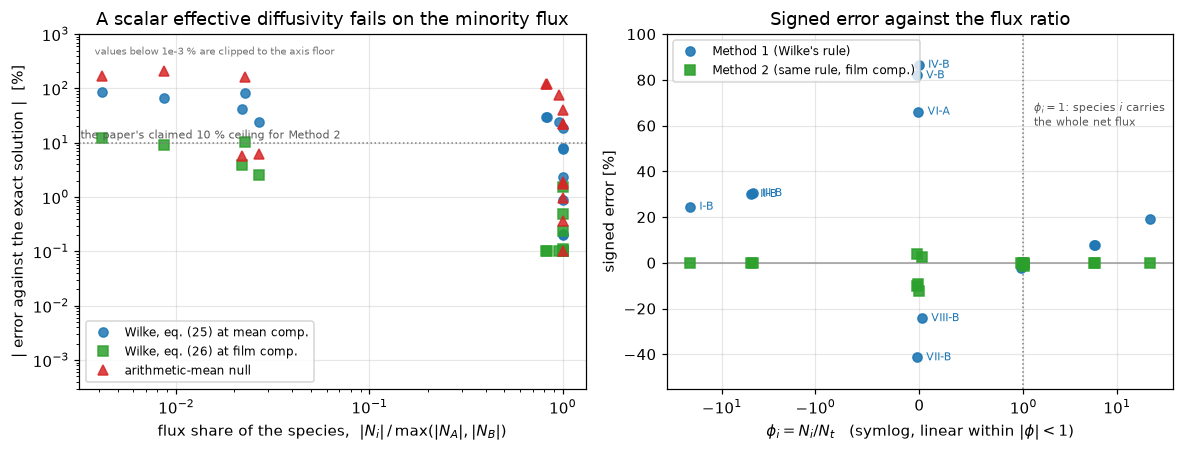

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.2))
ax = axes[0]
for lab, col, c, mk in (("Wilke, eq. (25) at mean comp.", "m1_err", "C0", "o"),
                        ("Wilke, eq. (26) at film comp.", "m2_err", "C2", "s"),
                        ("arithmetic-mean null", "null_err", "C3", "^")):
    ax.loglog(np.maximum(H.share, 3e-3), 100 * H[col].abs().clip(lower=1e-3),
              mk, ms=6, color=c, label=lab, alpha=0.85)
ax.axhline(10, color="0.5", ls=":", lw=1)
ax.annotate("the paper's claimed 10 % ceiling for Method 2", xy=(3.2e-3, 12),
            fontsize=7.5, color="0.35")
ax.set_xlabel("flux share of the species,  $|N_i|\\,/\\,\\max(|N_A|,|N_B|)$")
ax.set_ylabel("| error against the exact solution |  [%]")
ax.set_ylim(3e-4, 1e3)
ax.set_title("A scalar effective diffusivity fails on the minority flux")
ax.legend(fontsize=8, loc="lower left")
ax.text(0.03, 0.965, "values below 1e-3 % are clipped to the axis floor",
        transform=ax.transAxes, fontsize=6.5, color="0.45", va="top")

ax = axes[1]
ax.axhline(0, color="0.6", lw=1)
ax.axvline(1.0, color="0.5", ls=":", lw=1)
for lab, col, c, mk in (("Method 1 (Wilke's rule)", "m1_err", "C0", "o"),
                        ("Method 2 (same rule, film comp.)", "m2_err", "C2", "s")):
    ax.plot(H.phi, 100 * H[col], mk, ms=6, color=c, label=lab, alpha=0.9)
for r in H.itertuples():                      # markers only: the points are not a curve
    if abs(r.m1_err) > 0.2:
        ax.annotate(f"{r.example}-{r.species}", (r.phi, 100 * r.m1_err),
                    textcoords="offset points", xytext=(6, -2), fontsize=7,
                    color="C0")
ax.set_xscale("symlog", linthresh=1.0)
ax.set_xlabel("$\\phi_i = N_i/N_t$   (symlog, linear within $|\\phi|<1$)")
ax.set_ylabel("signed error [%]")
ax.set_title("Signed error against the flux ratio")
ax.set_ylim(-55, 100)
ax.annotate("$\\phi_i = 1$: species $i$ carries\nthe whole net flux", xy=(1.3, 60),
            fontsize=7.5, color="0.35")
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout(); plt.show()

### The paper's own accuracy claim for Method 2

Journal p. 100, quoted exactly as printed: *"Comparison with results of Method 3
indicates satisfactory agreement in all examples with a maximum **derivation**
[sic] of less than 10%."* The word is crisp on the 400-ppi crop — it is the
author's or the compositor's slip for *deviation*, and like every other printed
defect on this page it is reported rather than repaired. That is a checkable
statement, and it has two readings — against Wilke's own Method-3 column, or
against the true exact solution.

In [12]:
cl = float(pi[("method2_max_deviation_claim", "-", "2")])
own = []
for e in EXN:
    pref = T1[(T1.example == e) & (T1.m3_preferred == 1)].iloc[0]
    base = T1[T1.example == e].iloc[0]
    for i, spc in enumerate("AB"):
        own.append(dict(example=e, species=spc,
                        dev=as_pair(base, "m2")[i] / as_pair(pref, "m3")[i] - 1.0))
OWN = pd.DataFrame(own)
own_max = OWN.dev.abs().max()
own_row = OWN.loc[OWN.dev.abs().idxmax()]
ex_row = H.loc[H.m2_err.abs().idxmax()]
print(f"  claim, journal p. 100 : maximum deviation of Method 2 from Method 3 "
      f"< {cl:.0f} %\n")
print(f"  on WILKE'S OWN two printed columns : max {own_max:.2%} "
      f"(Example {own_row.example}, species {own_row.species})   "
      f"-> claim {'HOLDS' if own_max < cl/100 else 'FAILS'}")
print(f"  against the EXACT solution         : max {m2_max:.2%} "
      f"(Example {ex_row.example}, species {ex_row.species})   "
      f"-> claim {'HOLDS' if m2_max < cl/100 else 'FAILS'}")
print(f"\n  The claim is right about the arithmetic he did and wrong about the "
      f"physics by {100*m2_max-cl:.1f} points.")
print("  Both entries at issue are the MINORITY flux (share "
      f"{float(H[(H.example==ex_row.example)&(H.species==ex_row.species)].share.iloc[0]):.4f}), "
      "so the claim is\n  safe wherever the scalar diffusivity was going to be used "
      "for the dominant species.")

# ---- how far the first of those two numbers depends on the READING -----------
# The two alternative Method-3 N_B readings are recorded in the CSV's own
# read_note column; they are parsed from there, not retyped here.
ALT = {}
for _, r in T1.iterrows():
    m = re.search(r"alternative reading (-?[\d.]+)", str(r.read_note))
    if m:
        ALT[r.example] = float(m.group(1))


def own_dev_max(alt=None):
    d = []
    for e in EXN:
        pref = T1[(T1.example == e) & (T1.m3_preferred == 1)].iloc[0]
        base = T1[T1.example == e].iloc[0]
        for i in (0, 1):
            m3 = as_pair(pref, "m3")[i]
            if alt == e and i == 1:
                m3 = ALT[e]
            d.append(dict(example=e, species="AB"[i],
                          dev=abs(as_pair(base, "m2")[i] / m3 - 1.0)))
    D = pd.DataFrame(d)
    w = D.loc[D.dev.idxmax()]
    return float(w.dev), f"{w.example}-{w.species}"


print("\n  method2_max_dev_on_printed_columns is STRUCTURAL against computation -- no "
      "solve enters\n  it -- but it is NOT insensitive to the READING.  The two "
      f"Method-3 N_B cells with alternative\n  readings ({', '.join(f'{k} -> {v}' for k, v in ALT.items())}) "
      "move it:")
for tag, alt in [("as transcribed", None)] + [(f"Example {e} -> {v}", e)
                                              for e, v in ALT.items()]:
    v_, at = own_dev_max(alt)
    print(f"    {tag:>22} : max {v_:.2%}  at {at}")
print(f"  The paper's own '< {cl:.0f} %' claim survives every reading, but by "
      f"{cl - 100*max(own_dev_max(a)[0] for a in [None] + list(ALT)):.2f} "
      "points at worst rather\n  than "
      f"{cl - 100*own_max:.2f}.  The transcribed readings are what the page reports "
      "and nothing here\n  changes them; eq. (23) does not discriminate the pair "
      "(V2 above), and the page's own exact\n  solution sits "
      f"{abs(float(R[(R.example=='VII')&(R.species=='B')].m3_dev.iloc[0])):.1%} from "
      f"the transcribed {T1[(T1.example=='VII')].iloc[0].m3_NB:+.3f} against "
      f"{abs(EXACT['VII'][0][1]*SCALE/ALT['VII'] - 1):.1%} from the alternative -- but\n"
      "  that is corroboration, not a reading.  This row exists so the metric's "
      "sensitivity to the\n  reading is on the page rather than implied by the word "
      "'structural'.")

  claim, journal p. 100 : maximum deviation of Method 2 from Method 3 < 10 %

  on WILKE'S OWN two printed columns : max 9.07% (Example IV, species B)   -> claim HOLDS
  against the EXACT solution         : max 12.15% (Example IV, species B)   -> claim FAILS

  The claim is right about the arithmetic he did and wrong about the physics by 2.1 points.
  Both entries at issue are the MINORITY flux (share 0.0042), so the claim is
  safe wherever the scalar diffusivity was going to be used for the dominant species.

  method2_max_dev_on_printed_columns is STRUCTURAL against computation -- no solve enters
  it -- but it is NOT insensitive to the READING.  The two Method-3 N_B cells with alternative
  readings (VII -> -0.221, VIII -> 0.484) move it:
            as transcribed : max 9.07%  at IV-B
     Example VII -> -0.221 : max 9.95%  at VII-B
     Example VIII -> 0.484 : max 9.07%  at IV-B
  The paper's own '< 10 %' claim survives every reading, but by 0.05 points at worst rather
  than 0.9

### Example IV and Figure 3, recomputed rather than traced

For Example IV the paper obtains the CO₂ profile from eq. (2), plots $D'_{H_2O}$
from eq. (6) along it, and evaluates
$D''_{H_2O} = (x_2-x_1)\big/\!\int \mathrm{d}x/D'_{H_2O}$ **graphically**,
"found to be 2.15 sq.cm./sec. compared with 2.22 sq.cm./sec. calculated by
Equation (25)". Both numbers follow from the paper's own equations; no pixel is
read from the figure.

  D''_H2O from eq. (25), arithmetic-mean composition : 2.2222 (printed 2.22) -> +0.101%
  D''_H2O from the path integral (harmonic average)  : 2.1571 (printed 2.15) -> +0.330%
  the paper calls the gap 'small': it is +3.02%, while the Method-1 error on
  Example IV's water flux is +86.6% -- which is exactly the paper's own
  conclusion, that 'this small difference in D" could not account for the large error'.

  D'_H2O at the two film faces: 1.6401 and 3.4576 cm2/s (= D_BC = 3.4576 at
  the face where CO2 has vanished) -- consistent with Fig. 3's printed right-hand axis, 1.6 to 4.0.


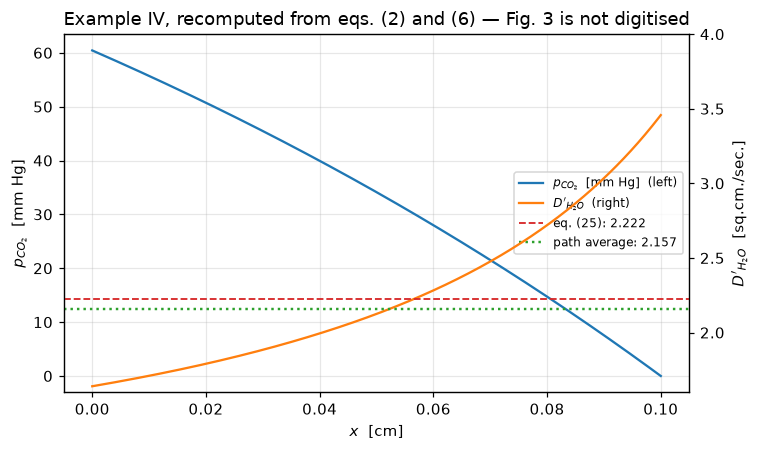

In [13]:
_, y1_IV, y2_IV, DAB4, DAC4, DBC4 = unpack("IV")
D4 = Dmat(DAB4, DAC4, DBC4)
yref4 = 0.5 * (y1_IV + y2_IV)
NA4, NB4 = EXACT["IV"][0]

D_eq25 = wilke_rule(yref4, 1, D4)


def prof_IV(x):
    """Exact SM composition profile at position x, from the closed form."""
    yA, yB = exact_closed(NA4, NB4, y1_IV, DAB4, DAC4, DBC4, x=x)
    return float(np.atleast_1d(yA)[0]), float(np.atleast_1d(yB)[0])


def Dp_B(x):
    yA, yB = prof_IV(x)
    return (1 - yB) / (yA / DAB4 + (1 - yA - yB) / DBC4)      # eq. (6) for H2O


def Dp_A_inert(x):
    yA, yB = prof_IV(x)
    yC = 1 - yA - yB
    fB, fC = yB / (yB + yC), yC / (yB + yC)                   # eq. (6a): inert only
    return 1.0 / (fB / DAB4 + fC / DAC4)


inv = quad(lambda x: 1.0 / Dp_B(x), 0.0, XLEN, limit=400, epsabs=1e-14, epsrel=1e-12)[0]
D_path = XLEN / inv
p_eq25, p_path = pi[("D_pp_H2O_eq25", "IV", "1")], pi[("D_pp_H2O_graphical", "IV", "-")]
print(f"  D''_H2O from eq. (25), arithmetic-mean composition : {D_eq25:.4f} "
      f"(printed {p_eq25}) -> {D_eq25/p_eq25-1:+.3%}")
print(f"  D''_H2O from the path integral (harmonic average)  : {D_path:.4f} "
      f"(printed {p_path}) -> {D_path/p_path-1:+.3%}")
print(f"  the paper calls the gap 'small': it is {D_eq25/D_path-1:+.2%}, while the "
      f"Method-1 error on\n  Example IV's water flux is "
      f"{float(H[(H.example=='IV')&(H.species=='B')].m1_err.iloc[0]):+.1%} -- which is exactly "
      "the paper's own\n  conclusion, that 'this small difference in D\" could not "
      "account for the large error'.")
print(f"\n  D'_H2O at the two film faces: {Dp_B(0.0):.4f} and {Dp_B(XLEN):.4f} "
      f"cm2/s (= D_BC = {DBC4:.4f} at\n  the face where CO2 has vanished) -- "
      "consistent with Fig. 3's printed right-hand axis, 1.6 to 4.0.")

xs = np.linspace(0, XLEN, 400)
fig, ax = plt.subplots(figsize=(7.0, 4.2))
ax.plot(xs, [prof_IV(x)[0] * P_MM for x in xs], color="C0",
        label="$p_{CO_2}$  [mm Hg]  (left)")
ax.set_xlabel("$x$  [cm]"); ax.set_ylabel("$p_{CO_2}$  [mm Hg]")
ax2 = ax.twinx(); ax2.grid(False)
ax2.plot(xs, [Dp_B(x) for x in xs], color="C1", label="$D'_{H_2O}$  (right)")
ax2.axhline(D_eq25, color="C3", ls="--", lw=1.2,
            label=f"eq. (25): {D_eq25:.3f}")
ax2.axhline(D_path, color="C2", ls=":", lw=1.6,
            label=f"path average: {D_path:.3f}")
ax2.set_ylabel("$D'_{H_2O}$  [sq.cm./sec.]"); ax2.set_ylim(1.6, 4.0)
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, fontsize=8, loc="center right")
ax.set_title("Example IV, recomputed from eqs. (2) and (6) — Fig. 3 is not digitised")
plt.tight_layout(); plt.show()

## Validation

### V1 — the three exact routes, and the grid order

The closed form and the matrix exponential are two integrations of the same
$2\times2$ system; the pymrm solve is a discretisation of it. Agreement between
the first two is close to structural and is labelled so; agreement of the third
with either is not, and it converges at a measured order.

In [14]:
two_route = []
for e in EXN:
    NA, NB = EXACT[e][0]
    _, y1, y2, DAB, DAC, DBC = unpack(e)
    a = np.array(exact_closed(NA, NB, y1, DAB, DAC, DBC)).ravel()[:2]
    b = np.array(exact_expm(NA, NB, y1, DAB, DAC, DBC)).ravel()[:2]
    two_route.append(np.max(np.abs(a - b)))
two_route_max = float(np.max(two_route))

alt = {e: exact_solve(e, route=exact_expm, n=40001) for e in EXN}
route_flux = float(max(max(abs(alt[e][0][i] / EXACT[e][0][i] - 1) for i in (0, 1))
                       for e in EXN))
print(f"V1a  closed form vs matrix exponential, y(x2) at the exact fluxes : "
      f"{two_route_max:.2e} (mole fraction)")
print(f"V1b  the two routes root-found INDEPENDENTLY, max relative flux difference: "
      f"{route_flux:.2e}")
print("     STRUCTURAL-ish: both integrate the same linear system, so this cannot "
      "detect a wrong\n     [B].  It does detect an algebra error in the closed-form "
      "eigenmode derivation, which is\n     why it is here.  The live companion is V1c.\n")

grid_rows = []
for e in EXN:
    prev = None
    for nz in (40, 80, 160, 320):
        f = SMFilm(e, n_z=nz); N = f.solve()
        err = max(abs(N[i] / EXACT[e][0][i] - 1) for i in (0, 1))
        order = np.nan if prev is None or err == 0 else np.log2(prev / err)
        grid_rows.append(dict(example=e, n_z=nz, err=err, order=order,
                              spread=f.flux_spread, newton_res=f.res, its=f.its))
        prev = err
G = pd.DataFrame(grid_rows)
print("V1c  pymrm finite volume against the closed form, refining the grid\n")
print(G.to_string(index=False, formatters={
    "err": lambda v: f"{v:.3e}", "spread": lambda v: f"{v:.2e}",
    "newton_res": lambda v: f"{v:.2e}",
    "order": lambda v: "   --" if np.isnan(v) else f"{v:5.2f}"}))
ord_mean = float(G.dropna().order.mean())
pm_err = float(G[G.n_z == 320].err.max())
spread_max = float(G.spread.max())
print(f"\n     mean observed order over 24 refinements = {ord_mean:.3f} "
      f"(second order, as the scheme is)")
print(f"     worst relative flux error at n_z = 320  = {pm_err:.2e}")
print(f"     worst flux non-uniformity (div N = 0)   = {spread_max:.2e}  "
      "-- STRUCTURAL, see the break table")

V1a  closed form vs matrix exponential, y(x2) at the exact fluxes : 2.39e-15 (mole fraction)
V1b  the two routes root-found INDEPENDENTLY, max relative flux difference: 1.18e-13
     STRUCTURAL-ish: both integrate the same linear system, so this cannot detect a wrong
     [B].  It does detect an algebra error in the closed-form eigenmode derivation, which is
     why it is here.  The live companion is V1c.



V1c  pymrm finite volume against the closed form, refining the grid

example  n_z       err order   spread newton_res  its
      I   40 2.096e-07   NaN 2.09e-14   6.04e-16    4
      I   80 5.215e-08  2.01 6.57e-14   2.41e-15    4
      I  160 1.301e-08  2.00 1.61e-13   1.46e-14    4
      I  320 3.248e-09  2.00 2.53e-13   6.21e-14    4
     II   40 3.500e-10   NaN 1.84e-12   1.54e-15    3
     II   80 8.703e-11  2.01 5.80e-12   9.60e-15    3
     II  160 2.176e-11  2.00 1.27e-11   4.19e-14    3
     II  320 5.454e-12  2.00 1.85e-11   1.09e-13    3
    III   40 9.819e-11   NaN 3.96e-12   1.46e-15    3
    III   80 2.392e-11  2.04 1.15e-11   6.20e-15    3
    III  160 6.016e-12  1.99 1.91e-11   2.55e-14    3
    III  320 2.083e-12  1.53 5.27e-11   1.69e-13    3
     IV   40 1.582e-04   NaN 1.60e-14   6.11e-16    4
     IV   80 3.935e-05  2.01 5.95e-14   3.93e-15    4
     IV  160 9.815e-06  2.00 1.61e-13   1.36e-14    4
     IV  320 2.451e-06  2.00 2.88e-13   8.30e-14    4
      V   40 

### V2 — Wilke's own eq. (23) as a constraint on the printed table

Eq. (23) is an exact integral of the equations Method 3 solves, so every printed
Method-3 pair must satisfy it. This is a check on the **reading**, not on the
page's computation, and it is the constraint that decides the ambiguous glyphs.

In [15]:
e23 = []
for _, r in T1.iterrows():
    if pd.isna(r.m3_NA):
        continue
    _, y1, y2, DAB, DAC, DBC = unpack(r.example)
    rhs = C_TOT / XLEN * np.log(y2[2] / y1[2])
    lhs = (r.m3_NA / DAC + r.m3_NB / DBC) / SCALE
    # what the printed rounding alone can produce: half a unit in the last
    # printed digit of each of the two entries, propagated through eq. (23).
    # SIG is read off the CSV's own printed literal, not inferred from the
    # float's repr - "0.330" would otherwise be counted as 2 significant
    # figures and give a 10x loose bound.
    bnd = (_half(r.m3_NA, SIG[(r.example, int(r.m3_set), "m3_NA")]) / DAC
           + _half(r.m3_NB, SIG[(r.example, int(r.m3_set), "m3_NB")]) / DBC
           ) / SCALE / abs(rhs)
    # ...and what the rounding of the two printed p_C values can produce on the
    # right-hand side, which the bound above ignores.
    lo = np.log((y2[2]*P_MM - 0.5*PSTEP[(r.example, "p2_C")])
                / (y1[2]*P_MM + 0.5*PSTEP[(r.example, "p1_C")]))
    hi = np.log((y2[2]*P_MM + 0.5*PSTEP[(r.example, "p2_C")])
                / (y1[2]*P_MM - 0.5*PSTEP[(r.example, "p1_C")]))
    pbnd = max(abs(lo / np.log(y2[2]/y1[2]) - 1), abs(hi / np.log(y2[2]/y1[2]) - 1))
    e23.append(dict(example=r.example, m3_set=int(r.m3_set),
                    NA=r.m3_NA, NB=r.m3_NB, resid=lhs / rhs - 1.0,
                    round_bound=bnd, full_bound=bnd + pbnd))
E23 = pd.DataFrame(e23)
E23["beyond_rounding"] = E23.resid.abs() > E23.round_bound
print(E23.to_string(index=False, formatters={
    "resid": lambda v: f"{v:+.4%}", "round_bound": lambda v: f"{v:8.4%}",
    "full_bound": lambda v: f"{v:8.4%}"},
    float_format=lambda v: f"{v:9.4f}"))
print("\n  round_bound propagates half a unit in the last printed digit of N_A and"
      " N_B only.\n  full_bound adds the same treatment of the two printed p_C values,"
      " which enter eq. (23)\n  through ln(p_C2/p_C1) -- and that term is where the"
      " ill-conditioned rows live: for\n  Example III the ratio is 50.028/49.972, a"
      " difference of 0.056 mm in 150, so half a unit in\n  the last printed digit"
      f" of each pressure alone is worth"
      f" {float(E23[E23.example=='III'].full_bound.iloc[0] - E23[E23.example=='III'].round_bound.iloc[0]):.2%}."
      "\n  The page's own check 1 is the argument that the printed pressures are NOT"
      " rounded: all\n  sixteen partial-pressure sums come to exactly 150 mm, which a"
      " rounded five-figure entry\n  would not do.  round_bound is therefore the"
      " bound the page believes, and full_bound is\n  carried beside it so that the"
      " conclusion can be checked without believing check 1.")
GROSS = 0.01                      # a miss that no hand-solution slop explains
ok23 = E23[E23.resid.abs() <= GROSS]
bad23 = E23[E23.resid.abs() > GROSS]
CONSISTENT = [(r.example, r.m3_set) for r in ok23.itertuples()]
e23_max_ok = float(ok23.resid.abs().max())
tight = E23[~E23.beyond_rounding]
print(f"\n  {len(tight)} of {len(E23)} pairs sit inside round_bound and "
      f"{int((E23.resid.abs() <= E23.full_bound).sum())} of {len(E23)} inside the "
      "wider full_bound.")
print(f"  {len(ok23)} of {len(E23)} sit inside 1 %, the worst of those being "
      f"{e23_max_ok:.2%} -- Wilke solved eqs.\n  (23) and (24) by hand, so a few tenths "
      "of a percent of solution error is expected and\n  is not a reading error.")
print(f"  {len(bad23)} miss GROSSLY (> {GROSS:.0%}): "
      + ", ".join(f"Example {r.example} set {r.m3_set} "
                  f"({r.resid:+.1%} against a {r.round_bound:.2%} rounding bound, "
                  f"{r.full_bound:.2%} with the pressures rounded too)"
                  for r in bad23.itertuples()))
print("  Example III is the most ill-conditioned row in the table -- its p_C moves by "
      "0.056 mm out\n  of 150 -- but both bounds say so quantitatively, and the "
      "miss is outside the wider one\n  by a factor of "
      f"{float(abs(E23[E23.example=='III'].resid.iloc[0]) / E23[E23.example=='III'].full_bound.iloc[0]):.1f}"
      ".  No single-digit repair reconciles it: holding N_A "
      "needs N_B = "
      f"{float((C_TOT/XLEN*np.log(unpack('III')[2][2]/unpack('III')[1][2]) - 0.0668/SCALE/2.7064)*3.4576*SCALE):+.4f}"
      ", holding N_B needs\n  N_A = "
      f"{float((C_TOT/XLEN*np.log(unpack('III')[2][2]/unpack('III')[1][2]) + 0.0528/SCALE/3.4576)*2.7064*SCALE):+.4f}"
      ", and the exact solution sits between the two.  Stored as printed.")

# Example I, set 3: which single digit is wrong?
_, y1I, y2I, DABI, DACI, DBCI = unpack("I")
rhsI = C_TOT / XLEN * np.log(y2I[2] / y1I[2])
NA_p, NB_p = 4.14, -3.93
print(f"\n  Example I set 3, printed ({NA_p}, {NB_p}):")
print(f"    holding N_A = {NA_p:.2f}, eq. (23) requires N_B = "
      f"{(rhsI - NA_p/SCALE/DACI)*DBCI*SCALE:+.4f}")
print(f"    holding N_B = {NB_p:.2f}, eq. (23) requires N_A = "
      f"{(rhsI - NB_p/SCALE/DBCI)*DACI*SCALE:+.4f}")
print("    the constraint says one digit is wrong but does NOT say which, so "
      "neither repair is\n    adopted and the CSV stores the pair as printed.")

# and none of the three sets except the preferred one solves the actual problem
print("\n  Do the three printed sets solve the boundary-value problem?  "
      "y_A at x_2 should be "
      f"{y2I[0]:.6f}:")
for tag, (na, nb) in (("set 1 (equimolal)", (5.64, -5.64)),
                      ("set 2 (preferred)", (4.862, -4.652)),
                      ("set 3 as printed", (4.14, -3.93)),
                      ("set 3, N_B repaired", (4.14, -3.723)),
                      ("set 3, N_A repaired", (4.301, -3.93))):
    yA, _ = exact_expm(na / SCALE, nb / SCALE, y1I, DABI, DACI, DBCI)
    v = float(np.atleast_1d(yA)[0])   # expm route: finite at N_t = 0, unlike the
                                      # closed form, whose f-mode divides by N_t
    print(f"    {tag:>22}: y_A(x_2) = {v:+.6f}   miss = {v - y2I[0]:+.6f}")
print(f"    exact solution found here : ({EXACT['I'][0][0]*SCALE:.4f}, "
      f"{EXACT['I'][0][1]*SCALE:.4f})")
print("    Set 1 is the equimolal root that eq. (23) alone admits: with N_A = -N_B,")
print(f"    N_A = (c/x) ln(p_C2/p_C1) / (1/D_AC - 1/D_BC) = "
      f"{rhsI/(1/DACI - 1/DBCI)*SCALE:.4f} in closed form, printed 5.64.")
print("    The paper says so itself: 'Selection of N_A = -N_B always satisfies "
      "Equations (23)\n    and (24) so that the equimolal roots have no unique "
      "significance.'")

example  m3_set        NA        NB     resid round_bound full_bound  beyond_rounding
      I       1    5.6400   -5.6400  -0.0329%     0.7272%    9.7709%            False
      I       2    4.8620   -4.6520  -0.4125%     0.0727%    9.1164%             True
      I       3    4.1400   -3.9300 -13.2097%     0.7272%    9.7709%             True
     II       1    0.1310   -0.1090  -0.1080%     1.9492%    2.8583%            False
    III       1    0.0668   -0.0528  +9.4078%     0.3829%    2.1686%             True
     IV       1   10.6200   -0.0441  +0.0403%     0.0476%    0.7189%            False
      V       1   10.2100   -0.2250  +0.1830%     0.0538%    0.7823%             True
     VI       1   -0.1050   13.4200  -0.0316%     0.0404%    2.4241%            False
    VII       1   10.6800   -0.2310  -0.1360%     0.0646%    0.7931%             True
   VIII       1   16.0900    0.4340  -0.0926%     0.0328%    1.3863%             True

  round_bound propagates half a unit in the last prin

### V3 — Taylor and Krishna's worked example, in the regime where the rule is exact

Example 8.5.1 of Taylor and Krishna (1993), printed pages 201–203: ethyl
propionate (1) evaporating into air (2) and hydrogen (3), $N_2 = N_3 = 0$. This
is the case Wilke's rule was derived for, and the case the paper's own Comment
section says is the only one with experimental support. Five printed
intermediates.

In [16]:
RG_SI, TK_K = 8.3143, 273.15 + tk["temperature"]
Pp = tk["pressure"] * 1e3
ell = tk["film_thickness"] * 1e-3
D12, D13 = tk["D_12"] * 1e-6, tk["D_13"] * 1e-6
y0 = np.array([tk["y_1_bulk"], tk["y_2_bulk"], tk["y_3_bulk"]])
yd = np.array([tk["y_1_interface"], tk["y_2_interface"], tk["y_3_interface"]])


def tk_chain_under(Rg_=RG_SI, T_=TK_K, ell_=ell, D_override=lambda t: t):
    """T&K's five printed intermediates as a function of every input a
    misreading could damage.  Re-run from the break table."""
    d12, d13 = D_override((D12, D13))
    ct_ = Pp / (Rg_ * T_)
    A11_ = 0.5 * (y0[1] + yd[1]) / d12 + 0.5 * (y0[2] + yd[2]) / d13
    Phi_ = np.log((1 - yd[0]) / (1 - y0[0]))
    Xi_ = 0.5 * Phi_ * (np.exp(Phi_) + 1) / (np.exp(Phi_) - 1)
    N1_ = ct_ * Xi_ * (y0[0] - yd[0]) / (A11_ * ell_)
    return [("c_t   mol/m3", ct_, tk["c_t"], 4), ("A_11  s/m2", A11_, tk["A_11"], 5),
            ("Phi", Phi_, tk["Phi"], 3), ("Xi", Xi_, tk["Xi"], 6),
            ("N_1   mol/m2 s", N1_, tk["N_1"], 3)]


def tk_devs(**kw):
    return [abs(c / p - 1.0) for _, c, p, _ in tk_chain_under(**kw)]


tk_chain = tk_chain_under()
ct, A11, Phi, Xi, N1 = (v for _, v, _, _ in tk_chain)
tk_dev = []
print(f"{'quantity':>16}{'printed':>12}{'recomputed':>14}{'rel dev':>11}{'print bound':>13}")
for name, comp, prt, sig in tk_chain:
    dev = abs(comp / prt - 1.0)
    tk_dev.append(dev)
    print(f"{name:>16}{prt:12.6g}{comp:14.7g}{dev:11.2%}{_pbound(prt, sig):13.2%}")
tk_max = float(np.max(tk_dev))
print(f"\n  all five reproduced, max relative deviation {tk_max:.3%}\n")

# the exact answer for this problem, in closed form (2 and 3 genuinely stagnant)
def tk_exact(y1d):
    return brentq(lambda N: 1 - y0[1]*np.exp(N*ell/(ct*D12))
                  - y0[2]*np.exp(N*ell/(ct*D13)) - y1d,
                  -5.0, -1e-9, xtol=1e-300, rtol=8.9e-16)


N1_ex = tk_exact(yd[0])
D_eff_tk = (1 - 0.5 * (y0[0] + yd[0])) / A11
N1_wilke = ct * D_eff_tk / ell * np.log((1 - yd[0]) / (1 - y0[0]))
print(f"  exact (species 2 and 3 stagnant, closed form) : N_1 = {N1_ex:.6f} mol/m2 s")
print(f"  Wilke D_1,eff = (1-y_1)/A_11 at the mean comp : {D_eff_tk*1e6:.4f} mm2/s"
      f"  ->  N_1 = {N1_wilke:.6f}")
print(f"  Burghardt-Krupiczka as printed by T&K         :        {N1:.6f}")
print(f"\n  IDENTITY, not agreement: Xi*(y_10 - y_1d) = (Phi/2)(2 - y_10 - y_1d) "
      "= (1 - y_1,mean) Phi,\n  so T&K's flux formula and Wilke's eq. (14) with"
      " phi_1 = 1 are the SAME expression in this\n  limit -- they agree to "
      f"{abs(N1_wilke/N1 - 1):.2e}, which is round-off and proves nothing about"
      " the\n  physics.  The live number is the next line.")
print(f"\n  frozen-composition error against the exact solution: "
      f"{N1_wilke/N1_ex - 1:+.4%}")

print("\n  ...and how that grows when the driving force widens (same three gases,\n"
      "  same stagnancy, only the interface mole fraction changed):")
sweep = []
for y1x in (yd[0], 0.2, 0.4, 0.6, 0.8):
    Ne = tk_exact(y1x)
    y2x, y3x = y0[1]*np.exp(Ne*ell/(ct*D12)), y0[2]*np.exp(Ne*ell/(ct*D13))
    A = 0.5*(y0[1]+y2x)/D12 + 0.5*(y0[2]+y3x)/D13
    Nw = ct*((1 - 0.5*(y0[0]+y1x))/A)/ell*np.log((1 - y1x)/(1 - y0[0]))
    sweep.append(dict(y1_interface=y1x, exact=Ne, wilke=Nw, err=Nw/Ne - 1))
S = pd.DataFrame(sweep)
print(S.to_string(index=False, formatters={"err": lambda v: f"{v:+.3%}"},
                  float_format=lambda v: f"{v:10.5f}"))
tk_stagnant_worst = float(S.err.abs().max())
print(f"\n  So 'exact for stagnant gases' is a statement about the POINTWISE"
      " coefficient, eq. (6.1.14).\n  The flux still needs an integration, and"
      f" freezing the rule at one composition costs\n  {S.err.abs().iloc[0]:.2%}"
      f" here and {tk_stagnant_worst:.1%} at y_1 = 0.8 -- with every N_j exactly zero.")

        quantity     printed    recomputed    rel dev  print bound
    c_t   mol/m3       40.21      40.21394      0.01%        0.01%
      A_11  s/m2       51318      51317.65      0.00%        0.00%
             Phi     -0.0655   -0.06549898      0.00%        0.08%
              Xi     1.00036      1.000357      0.00%        0.00%
  N_1   mol/m2 s     -0.0497   -0.04969977      0.00%        0.10%

  all five reproduced, max relative deviation 0.010%

  exact (species 2 and 3 stagnant, closed form) : N_1 = -0.049741 mol/m2 s
  Wilke D_1,eff = (1-y_1)/A_11 at the mean comp : 18.8688 mm2/s  ->  N_1 = -0.049700
  Burghardt-Krupiczka as printed by T&K         :        -0.049700

  IDENTITY, not agreement: Xi*(y_10 - y_1d) = (Phi/2)(2 - y_10 - y_1d) = (1 - y_1,mean) Phi,
  so T&K's flux formula and Wilke's eq. (14) with phi_1 = 1 are the SAME expression in this
  limit -- they agree to 2.22e-16, which is round-off and proves nothing about the
  physics.  The live number is the next line.



### V4 — the break table

Every metric reported in `agreement.json` needs a deliberate defect that moves
it. Rows below are injected one at a time into a clean recomputation, in four
tables: the headline errors, the reproduction of the printed cells, the
auxiliary metrics, and the two printed-intermediate chains. The coverage map at
the end is then **built from the measured mover list of each column**, not
written by hand — so a row that stops moving its metric shows up as a shorter
list rather than as a stale sentence. Two metrics cannot be moved by any
physical defect and are labelled **structural** with a live companion named.

In [17]:
def _movers(df, col, tol=1e-9):
    """The injected defects that actually move a column, by name."""
    base = df[col].iloc[0]
    return [df["injected defect"].iloc[i] for i in range(1, len(df))
            if abs(df[col].iloc[i] - base) > tol * max(1.0, abs(base))]


def rerun(**kw):
    """Recompute ALL SIX headline numbers under an injected defect, so that the
    coverage map can be built from measurement instead of assertion."""
    m1e, m2e, nle, sh = [], [], [], []
    for e in EXN:
        _, y1, y2, DAB, DAC, DBC = unpack(e)
        Do = kw.get("D_override", lambda t: t)((DAB, DAC, DBC))
        ex = exact_solve_D(e, Do)
        if ex is None:
            continue
        r1 = method1_D(e, Do, rule=kw.get("rule", wilke_rule),
                       comp=kw.get("comp", "mean"), x=kw.get("x", XLEN))
        r2 = method2_D(e, Do, clip=kw.get("clip", True))
        rn = method1_D(e, Do, rule=arith_rule)
        for i in (0, 1):
            m1e.append(abs(r1[i] / ex[i] - 1)); m2e.append(abs(r2[i] / ex[i] - 1))
            nle.append(abs(rn[i] / ex[i] - 1))
            sh.append(abs(ex[i]) / max(abs(ex[0]), abs(ex[1])))
    m1e, nle, sh = np.array(m1e), np.array(nle), np.array(sh)
    return (float(m1e.max()), float(np.median(m1e)),
            float(m1e[sh >= 0.5].max()), float(m1e[sh < 0.5].max()),
            float(max(m2e)), float(nle.max()), float(np.median(nle)))


def _with_D(e, Do):
    _, y1, y2, DAB, DAC, DBC = unpack(e)
    return y1, y2, Do[0], Do[1], Do[2]


def exact_solve_D(e, Do, n=40001):
    y1, y2, DAB, DAC, DBC = _with_D(e, Do)

    def F(NA):
        NA = np.atleast_1d(np.asarray(NA, float))
        NB = eq23_NB(NA, y1, y2, DAC, DBC)
        return exact_closed(NA, NB, y1, DAB, DAC, DBC)[0] - y2[0]
    grid = np.linspace(-2e-2, 2e-2, n)
    grid = grid[np.abs(grid) > 1e-12]
    rr = all_roots(F, grid)
    if not rr:
        return None
    return (rr[0], float(eq23_NB(rr[0], y1, y2, DAC, DBC)))


def method1_D(e, Do, rule=wilke_rule, comp="mean", x=XLEN):
    y1, y2, DAB, DAC, DBC = _with_D(e, Do)
    D = Dmat(DAB, DAC, DBC)
    yref = {"mean": 0.5*(y1+y2), "point1": y1, "point2": y2}[comp]
    KA, KB = C_TOT*rule(yref, 0, D)/x, C_TOT*rule(yref, 1, D)/x
    rts = film_roots(lambda r: (np.full(np.asarray(r, float).shape, KA),
                                np.full(np.asarray(r, float).shape, KB)), y1, y2)
    return rts[0]


def method2_D(e, Do, clip=True):
    y1, y2, DAB, DAC, DBC = _with_D(e, Do)
    D = Dmat(DAB, DAC, DBC)
    yref = 0.5*(y1+y2)

    def K(r):
        r = np.atleast_1d(np.asarray(r, float))
        KA, KB = np.empty_like(r), np.empty_like(r)
        for k, rk in enumerate(r):
            p = m2_pieces(yref, 1.0/(1.0+rk), D, clip)
            KA[k], KB[k] = C_TOT*p[0]/XLEN, C_TOT*p[1]/XLEN
        return KA, KB
    return film_roots(K, y1, y2)[0]


BREAKS = []
BREAKS.append(("(clean)", *rerun()))
BREAKS.append(("harmonic rule -> arithmetic mean (the null)",
               *rerun(rule=arith_rule)))
BREAKS.append(("freeze D at terminal 1 instead of the mean",
               *rerun(comp="point1")))
BREAKS.append(("swap D_AC <-> D_BC (a mis-assigned pair)",
               *rerun(D_override=lambda t: (t[0], t[2], t[1]))))
BREAKS.append(("D_AB x 1.5", *rerun(D_override=lambda t: (1.5*t[0], t[1], t[2]))))
BREAKS.append(("Method 2 negative-p_f clip disabled", *rerun(clip=False)))
BRCOL = ["m1_max", "m1_med", "m1_major", "m1_minor", "m2_max", "null_max", "null_med"]
BR = pd.DataFrame(BREAKS, columns=["injected defect"] + BRCOL)
print("break table -- headline error metrics under one injected defect at a time\n")
print(BR.to_string(index=False, float_format=lambda v: f"{v:8.4f}"))
BR_MOVERS = {c: _movers(BR, c) for c in BRCOL}
print("\n  rows that move each column: "
      f"{ {c: len(v) for c, v in BR_MOVERS.items()} }")
assert min(len(v) for v in BR_MOVERS.values()) >= 2
# the clean row must reproduce the numbers reported above, recomputed by a
# different code path (rerun) than the one that produced them
for got, want in zip(BREAKS[0][1:], (m1_max, m1_med, major.m1_err.abs().max(),
                                     minor.m1_err.abs().max(), m2_max,
                                     nl_max, nl_med)):
    assert abs(got / want - 1) < 1e-12, (got, want)
print("  the clean row reproduces all six reported headline numbers to 1e-12.")

break table -- headline error metrics under one injected defect at a time

                            injected defect   m1_max   m1_med  m1_major  m1_minor   m2_max  null_max  null_med
                                    (clean)   0.8665   0.2160    0.3050    0.8665   0.1215    2.1270    0.2224
harmonic rule -> arithmetic mean (the null)   2.1270   0.2224    1.2050    2.1270   0.1215    2.1270    0.2224
 freeze D at terminal 1 instead of the mean   0.9819   0.1659    0.9819    0.3804   0.1215    2.1270    0.2224
   swap D_AC <-> D_BC (a mis-assigned pair)   1.0573   0.0875    0.3135    1.0573   0.1957    1.9698    0.5699
                                 D_AB x 1.5   0.4460   0.1359    0.1977    0.4460   0.0356    0.7453    0.1205
        Method 2 negative-p_f clip disabled   0.8665   0.2160    0.3050    0.8665   0.4719    2.1270    0.2224

  rows that move each column: {'m1_max': 4, 'm1_med': 4, 'm1_major': 4, 'm1_minor': 4, 'm2_max': 3, 'null_max': 2, 'null_med': 2}
  the clean row r

In [18]:
# ---- break rows for the reproduction metrics (they compare against PRINTED cells)
def repro_under(rule=wilke_rule, comp="mean", clip=True, D_override=lambda t: t,
                Rg_=R_GAS, T_=T_K):
    global C_TOT
    keep = C_TOT
    C_TOT = P_ATM / (Rg_ * T_)
    try:
        d1, d2, d3, vi = [], [], [], np.nan
        for e in EXN:
            base = T1[T1.example == e].iloc[0]
            pref = T1[(T1.example == e) & (T1.m3_preferred == 1)].iloc[0]
            _, y1, y2, DAB, DAC, DBC = unpack(e)
            Do = D_override((DAB, DAC, DBC))
            r1 = method1_D(e, Do, rule=rule, comp=comp)
            r2 = method2_D(e, Do, clip=clip)
            r3 = exact_solve_D(e, Do)
            for i in (0, 1):
                dev1 = abs(r1[i]*SCALE/as_pair(base, "m1")[i] - 1)
                if e == "VI" and i == 0:
                    vi = dev1                       # the defect cell, kept separate
                elif not (e in ("I", "II") and i == 1):   # the two lost minus signs
                    d1.append(dev1)
                d2.append(abs(r2[i]*SCALE/as_pair(base, "m2")[i] - 1))
                d3.append(abs(r3[i]*SCALE/as_pair(pref, "m3")[i] - 1))
        return max(d1), max(d2), max(d3), vi
    finally:
        C_TOT = keep


base_rep = repro_under()
REP = [("(clean)", *base_rep),
       ("harmonic rule -> arithmetic mean", *repro_under(rule=arith_rule)),
       ("freeze D at terminal 1", *repro_under(comp="point1")),
       ("swap D_AC <-> D_BC", *repro_under(D_override=lambda t: (t[0], t[2], t[1]))),
       ("negative-p_f clip disabled", *repro_under(clip=False)),
       ("R = 82.06 -> 83.0 (+1.1 %)", *repro_under(Rg_=83.0)),
       ("T = 313.15 -> 316.3 K (+1 %)", *repro_under(T_=316.3))]
REPD = pd.DataFrame(REP, columns=["injected defect", "m1_repro", "m2_repro",
                                  "m3_repro", "exVI_m1_NA"])
print("\nbreak table -- reproduction of the PRINTED cells (Table 1) under the same "
      "defects\n")
print("  EXCLUSIONS, in full: m1_repro drops the two cells whose minus sign is missing"
      " (Method 1\n  N_B of Examples I and II) and carries the third defective cell"
      " (Method 1 N_A of Example VI)\n  in its own column rather than hiding it."
      "  m2_repro and m3_repro exclude NOTHING -- every\n  printed Method-2 and"
      " Method-3 cell of all eight examples is in them.\n")
print(REPD.to_string(index=False, float_format=lambda v: f"{v:9.5f}"))
REP_MOVERS = {c: _movers(REPD, c) for c in REPD.columns[1:]}
print("\n  rows that move each column: "
      f"{ {c: len(v) for c, v in REP_MOVERS.items()} }")
assert min(len(v) for v in REP_MOVERS.values()) >= 2
_m3worst = R.loc[R.m3_dev.abs().idxmax()]
_m3next = R.drop(R.m3_dev.abs().idxmax()).m3_dev.abs().max()
print(f"\n  m3_repro is set by Example {_m3worst.example}, species {_m3worst.species}"
      f" ({_m3worst.gas}): printed {_m3worst.m3_print:+.3f} against the exact"
      f"\n  {_m3worst.m3_calc:+.6f}, i.e. {abs(_m3worst.m3_dev):.2%}."
      f"  The next largest Method-3 miss is {_m3next:.2%}, so this one cell"
      f"\n  carries the metric by a factor of {abs(_m3worst.m3_dev)/_m3next:.1f}."
      "  It is NOT excluded and it is not a reading\n  error: it is Wilke's own"
      " hand solution of the transcendental pair, and it fails on exactly the"
      "\n  species this page's headline is about -- the MINORITY flux, whose share"
      " here is"
      f" {float(H[(H.example=='VI')&(H.species=='A')].share.iloc[0]):.4f}.\n"
      "  Two corroborating observations, neither of which is used to exclude it.")
_vi = T1[T1.example == "VI"].iloc[0]
_viA, _viB = _vi.m3_NA / BASE.loc["VI", "D_AC"], _vi.m3_NB / BASE.loc["VI", "D_BC"]
_vires = float(E23[E23.example == "VI"].resid.iloc[0])
print(f"  (a) The same {_vi.m2_NA:+.3f} is printed in the Method-2 column of the same"
      f" row, where it is right to\n      "
      f"{abs(float(R[(R.example=='VI')&(R.species=='A')].m2_dev.iloc[0])):.2%}"
      " -- so the Method-3 entry may simply have been carried across.\n"
      f"  (b) The page's own eq.-(23) test cannot see this cell: N_A/D_AC is"
      f" {abs(_viA)/abs(_viA + _viB):.1%} of eq. (23)'s\n      left-hand side for"
      f" Example VI, so that row's {_vires:+.2%} residual is silent about N_A and is"
      "\n      no defence of it.")
print("\nThe last two rows are the R and T sensitivity: a 1 % change in either moves"
      " the absolute\nrates by 1 % and therefore moves the reproduction of the printed"
      " table, but leaves every\nmethod-vs-method error in the previous table"
      " unchanged to 1e-13, because c = P/RT cancels\nin a ratio of two fluxes"
      " computed at the same conditions.  That is why the headline is a ratio.")

# the structural metrics, and what cannot move them
print("\nSTRUCTURAL quantities, declared:")
print(f"  flux uniformity max|N/mean(N) - 1| = {spread_max:.2e} -- this IS the"
      " converged Newton\n    residual re-expressed: div N = 0 with nu = 0 on a"
      " Cartesian grid forces it, so a wrong\n    D_AB leaves it at machine zero"
      " while changing the answer outright.  It detects an\n    unconverged solve"
      " and a wrong nu, nothing else.  It lands just ABOVE\n    ABS_FLOOR = 1e-12,"
      " where check_agreement.py WOULD compare it at REL_TOL = 5 % -- a"
      "\n    round-off residual that a different BLAS or SciPy will move by far more"
      " than that.  It is\n    therefore printed here as a solver diagnostic and"
      " kept OUT of agreement.json rather than\n    shipped as a false-alarm"
      " generator.  Live companion: pymrm_vs_closed_form_reldiff_n320.")
print(f"  partial-pressure sum residue      = {sum_dev:.2e} -- exactly zero and"
      " a property of the\n    PRINTED table, not of any computation here."
      "  Below ABS_FLOOR.  Companion: eq23_max_resid.")
print(f"  closed form vs matrix exponential = {two_route_max:.2e} -- two"
      " integrations of one\n    system.  Companion: pymrm_vs_closed_form, which"
      " shares no algebra with either.")


break table -- reproduction of the PRINTED cells (Table 1) under the same defects

  EXCLUSIONS, in full: m1_repro drops the two cells whose minus sign is missing (Method 1
  N_B of Examples I and II) and carries the third defective cell (Method 1 N_A of Example VI)
  in its own column rather than hiding it.  m2_repro and m3_repro exclude NOTHING -- every
  printed Method-2 and Method-3 cell of all eight examples is in them.

                 injected defect  m1_repro  m2_repro  m3_repro  exVI_m1_NA
                         (clean)   0.01925   0.05801   0.10420     0.85233
harmonic rule -> arithmetic mean   0.68750   0.05801   0.10420     2.48606
          freeze D at terminal 1   0.66473   0.05801   0.10420     0.28913
              swap D_AC <-> D_BC   3.92106   1.83195   1.98912     0.37638
      negative-p_f clip disabled   0.01925   0.51512   0.10420     0.85233
      R = 82.06 -> 83.0 (+1.1 %)   0.01751   0.06868   0.09169     0.83135
    T = 313.15 -> 316.3 K (+1 %)   0.01615  

In [19]:
# ---- break rows for the remaining metrics -------------------------------
def aux_metrics(rule=wilke_rule, comp="mean", D_override=lambda t: t):
    """D''(eq 25), the path average, (p_f)_A of Example VI and the eq-(23)
    residual, recomputed under one injected defect."""
    Do4 = D_override((BASE.loc["IV", "D_AB"], BASE.loc["IV", "D_AC"],
                      BASE.loc["IV", "D_BC"]))
    D4x = Dmat(*Do4)
    yref4x = 0.5 * (unpack("IV")[1] + unpack("IV")[2])
    de = rule(yref4x, 1, D4x) if comp == "mean" else rule(unpack("IV")[1], 1, D4x)
    ex4 = exact_solve_D("IV", Do4)

    def DpB(x):
        yA, yB = exact_closed(ex4[0], ex4[1], unpack("IV")[1], *Do4, x=x)
        yA, yB = float(np.atleast_1d(yA)[0]), float(np.atleast_1d(yB)[0])
        return (1 - yB) / (yA / Do4[0] + (1 - yA - yB) / Do4[2])
    dp = XLEN / quad(lambda x: 1.0 / DpB(x), 0.0, XLEN, limit=400)[0]

    Do6 = D_override((BASE.loc["VI", "D_AB"], BASE.loc["VI", "D_AC"],
                      BASE.loc["VI", "D_BC"]))
    n6 = method1_D("VI", Do6, rule=rule, comp=comp)
    pf6 = pf_A_of(n6[0], n6[1], y1_VI, y2_VI)

    res = []
    for _, r in T1.iterrows():
        if pd.isna(r.m3_NA) or (r.example, int(r.m3_set)) not in CONSISTENT:
            continue                                  # the SAME fixed row set
        _, y1, y2, DAB, DAC, DBC = unpack(r.example)
        DABx, DACx, DBCx = D_override((DAB, DAC, DBC))
        rhs = C_TOT / XLEN * np.log(y2[2] / y1[2])
        res.append(abs((r.m3_NA / DACx + r.m3_NB / DBCx) / SCALE / rhs - 1))
    return (abs(de / p_eq25 - 1), abs(dp / p_path - 1), abs(pf6 / pf_stated - 1),
            float(np.max(res)))


AUX = [("(clean)", *aux_metrics()),
       ("harmonic rule -> arithmetic mean", *aux_metrics(rule=arith_rule)),
       ("freeze D at terminal 1", *aux_metrics(comp="point1")),
       ("swap D_AC <-> D_BC", *aux_metrics(D_override=lambda t: (t[0], t[2], t[1]))),
       ("D_AB x 1.5", *aux_metrics(D_override=lambda t: (1.5 * t[0], t[1], t[2]))),
       ("D_BC x 1.2", *aux_metrics(D_override=lambda t: (t[0], t[1], 1.2 * t[2])))]
AUXD = pd.DataFrame(AUX, columns=["injected defect", "eq25_DppB", "path_DppB",
                                  "pf_A_exVI", "eq23_resid"])
print("break table -- the auxiliary metrics (each is a deviation from a PRINTED "
      "number)\n")
print(AUXD.to_string(index=False, float_format=lambda v: f"{v:9.5f}"))
AUX_MOVERS = {c: _movers(AUXD, c) for c in AUXD.columns[1:]}
print("\n  rows that move each column: "
      f"{ {c: len(v) for c, v in AUX_MOVERS.items()} } -- none of the four is an "
      "identity.")
assert min(len(v) for v in AUX_MOVERS.values()) >= 2

break table -- the auxiliary metrics (each is a deviation from a PRINTED number)

                 injected defect  eq25_DppB  path_DppB  pf_A_exVI  eq23_resid
                         (clean)    0.00101    0.00330    0.00212     0.00413
harmonic rule -> arithmetic mean    0.32660    0.00330    0.20251     0.00413
          freeze D at terminal 1    0.26120    0.00330    0.21369     0.00413
              swap D_AC <-> D_BC    0.12372    0.11644    0.27067     2.10703
                      D_AB x 1.5    0.19509    0.21047    0.16401     0.00413
                      D_BC x 1.2    0.09456    0.09198    0.14185     0.59993

  rows that move each column: {'eq25_DppB': 5, 'path_DppB': 3, 'pf_A_exVI': 5, 'eq23_resid': 2} -- none of the four is an identity.


The two printed-intermediate chains — the p. 101 sample
calculation and Taylor and Krishna's Example 8.5.1 — need break rows of their
own. Neither is touched by any row above: the reproduction table rebinds $c$ and
the diffusivities of the *film* problem, and the V3 stagnant sweep produces a
different metric (`stagnant_frozen_composition_worst_err`), not these. Both
chains are re-run below with one input deliberately misread.

In [20]:
# ---- break rows for the two printed-intermediate chains ------------------
CHAINS = [
    ("(clean)", {}, {}),
    ("R + 1.1 % (82.06 -> 83.0 ; 8.3143 -> 8.4058)",
     dict(Rg_=83.0), dict(Rg_=8.3143 * 83.0 / 82.06)),
    ("T + 1 % (313.15 -> 316.3 K ; 303.05 -> 306.1 K)",
     dict(T_=316.3), dict(T_=306.1)),
    ("film thickness x 1.1 (0.1 -> 0.11 cm ; 1.0 -> 1.1 mm)",
     dict(x=0.11), dict(ell_=1.1e-3)),
    ("swap the two diffusivities the chain uses",
     dict(D_override=lambda t: (t[0], t[2], t[1])),
     dict(D_override=lambda t: (t[1], t[0]))),
    ("D_AB / D_12 x 1.2",
     dict(D_override=lambda t: (1.2 * t[0], t[1], t[2])),
     dict(D_override=lambda t: (1.2 * t[0], t[1]))),
]
CH = pd.DataFrame([(lab, float(np.max(sample_devs(**ks))), float(np.max(tk_devs(**kt))))
                   for lab, ks, kt in CHAINS],
                  columns=["injected defect", "sample_max", "tk_max"])
print("break table -- the two printed-intermediate chains, one misread input at a "
      "time\n")
print(CH.to_string(index=False, float_format=lambda v: f"{v:10.6f}"))
CH_MOVERS = {c: _movers(CH, c) for c in ("sample_max", "tk_max")}
print("\n  rows that move each column: "
      f"{ {c: len(v) for c, v in CH_MOVERS.items()} } -- neither chain metric is an "
      "identity.")
assert min(len(v) for v in CH_MOVERS.values()) >= 2
print("  Both are genuine reproductions of numbers someone else printed, so a "
      "misread R, T, film\n  thickness or diffusivity moves them and the paper "
      "catches it.  Note how far: a 1.1 %\n  error in R alone takes the sample "
      f"chain from {CH.sample_max.iloc[0]:.2%} to {CH.sample_max.iloc[1]:.2%} and "
      f"the T&K chain from {CH.tk_max.iloc[0]:.4%}\n  to {CH.tk_max.iloc[1]:.2%}, "
      "both far outside the paper's own print-rounding bounds.")

break table -- the two printed-intermediate chains, one misread input at a time

                                      injected defect  sample_max     tk_max
                                              (clean)    0.002881   0.000098
         R + 1.1 % (82.06 -> 83.0 ; 8.3143 -> 8.4058)    0.012072   0.011330
      T + 1 % (313.15 -> 316.3 K ; 303.05 -> 306.1 K)    0.010707   0.009969
film thickness x 1.1 (0.1 -> 0.11 cm ; 1.0 -> 1.1 mm)    0.091596   0.090913
            swap the two diffusivities the chain uses    0.015753   0.724354
                                    D_AB / D_12 x 1.2    0.190474   0.119653

  rows that move each column: {'sample_max': 5, 'tk_max': 5} -- neither chain metric is an identity.
  Both are genuine reproductions of numbers someone else printed, so a misread R, T, film
  thickness or diffusivity moves them and the paper catches it.  Note how far: a 1.1 %
  error in R alone takes the sample chain from 0.29% to 1.21% and the T&K chain from 0.0098%
  to 1.1

In [21]:
metrics = {
    # --- reproduction of what the paper prints
    "sample_calc_max_reldev": sample_max,
    "table1_method1_repro_max_reldev": base_rep[0],
    "table1_method2_repro_max_reldev": base_rep[1],
    "table1_method3_repro_max_reldev": base_rep[2],
    "table1_exampleVI_method1_NA_dev": base_rep[3],
    "eq25_DppB_exampleIV_reldev": abs(D_eq25 / p_eq25 - 1),
    "path_average_DppB_exampleIV_reldev": abs(D_path / p_path - 1),
    "pf_A_exampleVI_method1_reldev": abs(pf_calc / pf_stated - 1),
    "eq23_max_resid_consistent_rows": e23_max_ok,
    "taylor_krishna_851_max_reldev": tk_max,
    # --- the headline: the rule against the exact solution
    "wilke_rule_max_err_vs_exact": float(m1_max),
    "wilke_rule_median_err_vs_exact": float(m1_med),
    "wilke_rule_max_err_majority_flux": float(major.m1_err.abs().max()),
    "wilke_rule_max_err_minority_flux": float(minor.m1_err.abs().max()),
    "method2_max_err_vs_exact": float(m2_max),
    "method2_max_dev_on_printed_columns": float(own_max),
    "arithmetic_null_max_err_vs_exact": float(nl_max),
    "arithmetic_null_median_err_vs_exact": float(nl_med),
    "stagnant_frozen_composition_worst_err": tk_stagnant_worst,
    # --- solver
    "pymrm_vs_closed_form_reldiff_n320": pm_err,
    "pymrm_observed_grid_order": ord_mean,
    "exact_two_routes_reldiff": route_flux,
}
def _rows(table, movers, col):
    """Name the break rows that were MEASURED to move a column, never asserted."""
    return f"{table}: " + "; ".join(movers[col])


COVER = {
    # --- taken from the measured mover lists of the four break tables
    "sample_calc_max_reldev": _rows("chain break table", CH_MOVERS, "sample_max"),
    "table1_method1_repro_max_reldev": _rows("reproduction break table", REP_MOVERS, "m1_repro"),
    "table1_method2_repro_max_reldev": _rows("reproduction break table", REP_MOVERS, "m2_repro"),
    "table1_method3_repro_max_reldev": _rows("reproduction break table", REP_MOVERS, "m3_repro"),
    "table1_exampleVI_method1_NA_dev": _rows("reproduction break table", REP_MOVERS, "exVI_m1_NA"),
    "eq25_DppB_exampleIV_reldev": _rows("auxiliary break table", AUX_MOVERS, "eq25_DppB"),
    "path_average_DppB_exampleIV_reldev": _rows("auxiliary break table", AUX_MOVERS, "path_DppB"),
    "pf_A_exampleVI_method1_reldev": _rows("auxiliary break table", AUX_MOVERS, "pf_A_exVI"),
    "eq23_max_resid_consistent_rows": _rows("auxiliary break table", AUX_MOVERS, "eq23_resid"),
    "taylor_krishna_851_max_reldev": _rows("chain break table", CH_MOVERS, "tk_max"),
    "wilke_rule_max_err_vs_exact": _rows("headline break table", BR_MOVERS, "m1_max"),
    "wilke_rule_median_err_vs_exact": _rows("headline break table", BR_MOVERS, "m1_med"),
    "wilke_rule_max_err_majority_flux": _rows("headline break table", BR_MOVERS, "m1_major"),
    "wilke_rule_max_err_minority_flux": _rows("headline break table", BR_MOVERS, "m1_minor"),
    "method2_max_err_vs_exact": _rows("headline break table", BR_MOVERS, "m2_max"),
    "arithmetic_null_max_err_vs_exact": _rows("headline break table", BR_MOVERS, "null_max"),
    "arithmetic_null_median_err_vs_exact": _rows("headline break table", BR_MOVERS, "null_med"),
    # --- the rest, argued rather than tabulated
    "method2_max_dev_on_printed_columns": "STRUCTURAL - against COMPUTATION only: it compares "
                                          "two printed columns and no solve enters it. It is "
                                          "NOT insensitive to the READING, and the "
                                          "alternative-reading rows printed in Results move it "
                                          "(9.07 % -> 9.95 %)",
    "stagnant_frozen_composition_worst_err": "the V3 stagnant sweep is itself the break row",
    "pymrm_vs_closed_form_reldiff_n320": "grid refinement (order 2.0 measured)",
    "pymrm_observed_grid_order": "grid refinement",
    "exact_two_routes_reldiff": "STRUCTURAL - two integrations of one system; "
                                "companion pymrm_vs_closed_form_reldiff_n320",
}
assert set(COVER) == set(metrics), (set(metrics) ^ set(COVER))
assert all(not v.endswith(": ") for v in COVER.values())   # no empty mover list
ABS_FLOOR = 1e-12
below = [k for k, v in metrics.items() if abs(v) < ABS_FLOOR]
print("coverage map asserted key-for-key against agreement.json.  Every 'moved by' list\n"
      "below is the MEASURED mover list of a break table above, not a claim.\n")
for k in metrics:
    tag = "STRUCTURAL" if COVER[k].startswith("STRUCTURAL") else "moved by"
    print(f"  {k}\n      {tag}: " + "\n      ".join(textwrap.wrap(
        COVER[k].removeprefix("STRUCTURAL - "), 84)))
print(f"\nmetrics below ABS_FLOOR = {ABS_FLOOR:g} (outside CI comparison): "
      f"{below if below else 'none'}")
print(f"\nNOT reported to CI: flux uniformity max|N/mean(N) - 1| = {spread_max:.2e}."
      "  It is the converged\n  Newton residual re-expressed, no physical defect"
      " moves it, and it happens to land just\n  ABOVE ABS_FLOOR = 1e-12 -- so"
      " check_agreement.py would compare a round-off residual at\n  REL_TOL = 5 %"
      " and fail on any other BLAS or SciPy for no physical reason.  It is printed"
      "\n  on the page as a solver diagnostic and deliberately kept out of"
      " agreement.json.")
report_agreement("A4.1", metrics)

coverage map asserted key-for-key against agreement.json.  Every 'moved by' list
below is the MEASURED mover list of a break table above, not a claim.

  sample_calc_max_reldev
      moved by: chain break table: R + 1.1 % (82.06 -> 83.0 ; 8.3143 -> 8.4058); T + 1 % (313.15 ->
      316.3 K ; 303.05 -> 306.1 K); film thickness x 1.1 (0.1 -> 0.11 cm ; 1.0 -> 1.1 mm);
      swap the two diffusivities the chain uses; D_AB / D_12 x 1.2
  table1_method1_repro_max_reldev
      moved by: reproduction break table: harmonic rule -> arithmetic mean; freeze D at terminal 1;
      swap D_AC <-> D_BC; R = 82.06 -> 83.0 (+1.1 %); T = 313.15 -> 316.3 K (+1 %)
  table1_method2_repro_max_reldev
      moved by: reproduction break table: swap D_AC <-> D_BC; negative-p_f clip disabled; R = 82.06
      -> 83.0 (+1.1 %); T = 313.15 -> 316.3 K (+1 %)
  table1_method3_repro_max_reldev
      moved by: reproduction break table: swap D_AC <-> D_BC; R = 82.06 -> 83.0 (+1.1 %); T = 313.15
      -> 316.3 K (+1 %)
  

{'page': 'A4.1',
 'metrics': {'sample_calc_max_reldev': 0.002881294840145876,
  'table1_method1_repro_max_reldev': 0.019245017808931175,
  'table1_method2_repro_max_reldev': 0.05800682092097542,
  'table1_method3_repro_max_reldev': 0.10419728907220693,
  'table1_exampleVI_method1_NA_dev': 0.8523298937164041,
  'eq25_DppB_exampleIV_reldev': 0.0010085850253436224,
  'path_average_DppB_exampleIV_reldev': 0.0032959191009658273,
  'pf_A_exampleVI_method1_reldev': 0.0021163323561800285,
  'eq23_max_resid_consistent_rows': 0.004125400222200426,
  'taylor_krishna_851_max_reldev': 9.800309836149879e-05,
  'wilke_rule_max_err_vs_exact': 0.8664673963657779,
  'wilke_rule_median_err_vs_exact': 0.2160210993538204,
  'wilke_rule_max_err_majority_flux': 0.3049671670906573,
  'wilke_rule_max_err_minority_flux': 0.8664673963657779,
  'method2_max_err_vs_exact': 0.12148135700346008,
  'method2_max_dev_on_printed_columns': 0.09070294784580502,
  'arithmetic_null_max_err_vs_exact': 2.1270320603016444,
  '

## What pymrm adds

Honestly: **not the answer**. The exact problem here is a $2\times2$ linear
system with constant coefficients, and it has a closed-form solution that this
page derives and uses. A finite-volume solver is not needed to reproduce
Wilke's Table 1 and the page does not pretend it is.

What the pymrm route does add is three things the closed form cannot give:

1. **An independent check on the derivation.** The closed form rests on
   spotting that $y_C$ is an eigenmode with rate $\lambda_C$ and that
   $f = N_B y_A - N_A y_B$ obeys a forced first-order equation with rate
   $\lambda_2 = N_t/(cD_{AB})$. That is exactly the kind of algebra that is
   confidently wrong. `construct_grad` + `construct_div` + `NumJac` + Newton
   knows none of it — it only knows $N = -c[B]^{-1}\nabla y$ and
   $\nabla\!\cdot\! N = 0$ — and it converges onto the closed form at a measured
   order of 2.0 across all eight examples. That is the check that could have
   failed, and it is why the closed form is trusted enough to be used as the
   reference everywhere else on the page.

2. **The route that survives when the linearity does not.** The closed form
   exists only because $c$, $T$, $P$ and every $D_{ij}$ are constant and $N_C$
   is exactly zero. Drop any one of those — a reacting film, a pressure
   gradient, composition-dependent $D_{ij}$, a fourth species with its own flux
   — and the analytic route disappears while the pymrm residual is unchanged in
   form. The `Reuse` section below is written around that.

3. **The profiles, at no extra cost.** Figure 3's two curves — the CO₂ pressure
   profile and $D'_{H_2O}(x)$ along it — are what Wilke had to construct
   graphically and integrate by planimeter, and the page recomputes both instead
   of digitising them.

What the *page* adds beyond the paper is separable from the solver:

- **The rule is measured where it is not exact.** Wilke prints the comparison but
  never reduces it to a number; the paper's own summary of Method 1 is
  qualitative ("good agreement when the component under consideration is
  diffusing at a relatively high rate compared with that of the other component,
  and poor agreement otherwise"). Quantified against the exact solution: 87 %
  worst case, 22 % median, and the split is by **flux share** — a median of
  7.7 % on the species carrying the majority flux against 66 % on the minority.
- **The failure is attributed.** Swapping the harmonic average for the
  arithmetic one barely moves the median (22.2 % against 21.6 %) while making
  the worst case two and a half times worse (86.6 % to 212.7 %); keeping the
  harmonic average and moving the *composition*
  takes the worst case from 87 % to 12 %. The mixture rule's functional form is
  not what limits it.
- **A null baseline**, taken from the paper's own printed Discussion rather than
  invented.
- **The paper's own accuracy claim tested both ways** — it holds on Wilke's
  arithmetic (9.1 %) and fails on the true solution (12.2 %).
- **Three printed defects proved from the paper's own numbers**, and one
  ambiguity left unrepaired because the constraint does not decide it.
- **A statement of what "exact for stagnant gases" is worth**: it is a statement
  about the pointwise coefficient. Freezing that coefficient at one composition
  costs 0.08 % on Taylor and Krishna's example and 31 % when the driving force is
  widened, with every $N_j$ still exactly zero.

## Reuse

**When Wilke's rule is safe.** Species $i$ carries essentially all of the net
flux ($\phi_i \to 1$, or every other species stagnant), the driving force is
small, and you want the flux of *that* species. On this page's eight problems
that regime is Examples IV, V, VI, VII and VIII — every example whose dominant
species has $\phi \approx 1$, which includes Example VI's CO₂ at $\phi = 1.0087$,
where the rule is 0.90 % off — and the rule is within 2.4 % there without
exception.

**When it is not.** Anything you intend to read off the *minority* flux. Every
minority-flux entry here is 24–87 % wrong, and the sign of the error is not even
consistent (it is $+87\%$ on Example IV and $-41\%$ on Example VII). A scalar
effective diffusivity applied to all species at once also violates the flux
closure it is embedded in — page `A4.2` shows the same failure from the other
direction, on measurements, and reaches it through Krishna and Wesselingh's
review rather than through Wilke.

**The cheap fix is not a better mixture rule.** It is a better composition. The
harmonic-versus-arithmetic choice moves the median error by 0.6 points; moving
from the arithmetic-mean composition to Wilke's flux-weighted film composition
moves the worst case by 75 points. If a scalar diffusivity has to be used,
iterate it on the fluxes.

**Reusing the code.**

- `SMFilm` solves the exact ternary film with one stagnant species. To add a
  fourth species: widen `shape` to `(n_z, 3)`, extend `_M` with the general
  $B_{ii} = y_i/D_{in} + \sum_{k\neq i} y_k/D_{ik}$, $B_{ij} = -y_i(1/D_{ij} -
  1/D_{in})$, and keep `NumJac(shape, axes_diagonals=[0])` — `axes_blocks`
  defaults to the last axis, which is the species axis, and that is what you
  want.
- To make a species *react* at one face, change that face's `bc` dict rather
  than the residual: the boundary condition is on the **outward** normal, so
  $\{a: 1, b: 0, d: q\}$ means $\mathrm{d}y/\mathrm{d}x = -q$ at the left face
  and $+q$ at the right.
- `nu=0` in `construct_div` is the Cartesian film. A spherical pellet is
  `nu=2` and needs nothing else changed in the residual.
- `film_roots` is reusable for any two-species film-model closure: hand it a
  callable returning $(K_A, K_B)$ as a function of $r = N_B/N_A$ and it returns
  **every** root, not the first one a Newton iteration happens to find. Wilke's
  own paper warns that "selection of the proper set of solutions is not always
  obvious", and Example I is why.

**What this page cannot conclude.**

- Nothing about real carbon dioxide, water or hydrogen. The table's own footnote
  says the diffusivities "are estimated and do not correspond to true values",
  so every number here is a comparison *between methods* on identical inputs.
- Nothing measured. The paper's only experimental content is Figure 1, which is
  scoped out; the Comment section itself says the Stefan–Maxwell equations'
  validity "has not been established experimentally in multicomponent systems
  for other than the stagnant gas case". The exact solution is used here as the
  *reference*, and if the Stefan–Maxwell equations are wrong for these mixtures
  then so is every error bar on this page.
- Nothing about mixtures of more than three species. Every example is ternary,
  and Wilke says so himself of Method 2: "although the method has been tested
  only with the present three-component examples, it seems reasonable to assume
  that equally satisfactory results would be obtained in extending the method to
  systems of any number of components." That extrapolation is not tested here.
- Nothing about which digit is wrong in Example I's third Method-3 set. Eq. (23)
  proves one of the two is wrong and does not say which.

## References

Wilke, C. R. (1950). *Diffusional Properties of Multicomponent Gases*.
**Chemical Engineering Progress 46**(2) 95–104. — The source. Read in full on
renders at the scan's native 400 ppi; no DOI exists. Presented at the Ninth
Regional Meeting, Los Angeles. Every equation, every cell of Table 1 and every
printed intermediate used here was cropped and re-read at digit scale; the text
layer was not used for any character.

Arnold, J. H. (1950), and Sage, B. H. (1950). Discussion of the above,
**Chemical Engineering Progress 46**(2) 104. — Printed with the paper. Arnold's
contribution is the source of this page's null baseline: Wilke's expression "is
simply a weighted harmonic mean, as opposed to the weighted arithmetic mean
suggested by Hougen and Watson; the latter is badly in error in some cases."

Taylor, R. and Krishna, R. (1993). *Multicomponent Mass Transfer*. Wiley,
ISBN 0-471-57417-1. — The independent second witness, on disk and read at its
native 600 ppi. Section 6.1.3 (printed p. 126) prints the rule as eq. (6.1.14)
with "(Wilke, 1950)" inline and states its condition; section 8.6 (p. 204)
records the pedigree; Example 8.5.1 (pp. 201–203) is reproduced here in full.

Gilliland, E. R. and Sherwood, T. K. (1934). *Ind. Eng. Chem.* **26**, 516;
Sherwood, T. K. (1937). *Absorption and Extraction*, McGraw-Hill;
Hougen, O. A. and Watson, K. M. (1947). *Chemical Process Principles III*,
Wiley; Fairbanks, D. F. (1948). M.S. thesis, University of California;
Stefan, J. (1871, 1872, 1874). *Sitz. Akad. Wiss. Wien* **63**, **65**, **68**;
Maxwell, J. C. (1866, 1890). — **Origins not consulted.** These are Wilke's
refs. 12, 24, 16, 10, 29–31, 20–21, read off the Literature Cited on journal
p. 104. Note that Wilke's text cites "(25)" for both *"Sherwood (25) presents
differential equations"* and *"Gilliland (25) has integrated (21) and (22)"*,
but his ref. 25 is *Sherwood, T. K., Ibid., p. 11 (1937)* — the same book as
ref. 24 — while Gilliland & Sherwood (1934) is his ref. **12**. Both citations
of "(25)" therefore point at Sherwood's book, not at the 1934 paper.
Eqs. (21)–(24) reach this page **through**
Wilke's transcription of them, and eqs. (21)–(23) are independently re-derived
here from the Maxwell–Stefan balance rather than trusted. Hougen and Watson's
arithmetic-mean rule reaches this page through **Arnold's one-sentence
description of it** in the printed Discussion; their book was not opened and the
page never cites a form of it beyond what that sentence names.

Krishna, R. and Wesselingh, J. A. (1997). *Chemical Engineering Science* **52**,
861–911. — Not used here. It is the source of sibling pages `A4.2`, `A4.3` and
`A4.4`, which reach a related conclusion about scalar effective diffusivities by
a wholly different route and on measured data.